In [222]:
import pandas as pd

In [246]:
df = pd.read_csv("./score.txt")

In [247]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [248]:
df.shape

(25, 2)

In [249]:
X = df.drop('Scores', axis = 1)
y = df['Scores']

<Axes: xlabel='Hours', ylabel='Scores'>

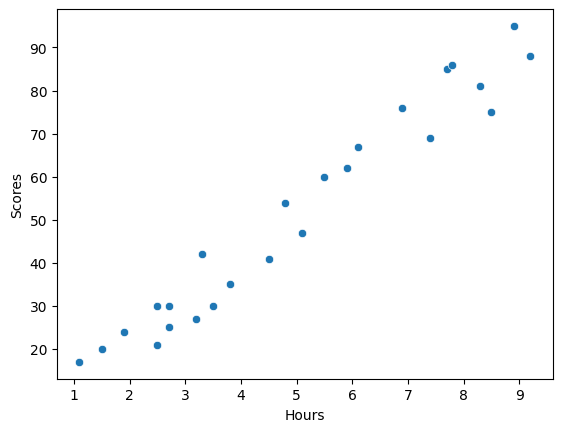

In [250]:
import seaborn as sns
sns.scatterplot(x = df["Hours"], y = y)

In [251]:
df[['Hours', 'Scores']].corr()

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


<Axes: >

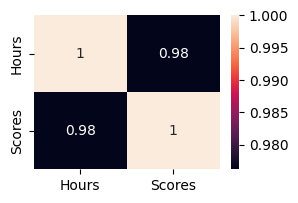

In [252]:
import matplotlib.pyplot as plt
plt.figure(figsize = (3, 2))
sns.heatmap(df[['Hours', 'Scores']].corr(), annot = True)

In [253]:
from sklearn.model_selection import train_test_split

In [254]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.7, random_state = 0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17, 1), (8, 1), (17,), (8,))

In [255]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [256]:
scaler = StandardScaler()
ct = ColumnTransformer([('hours', scaler, ['Hours'])],
                       remainder = 'passthrough',
                       verbose_feature_names_out = False,
                       force_int_remainder_cols = False).set_output(transform = 'pandas')
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('hours', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{f

In [257]:
X_train_transformed = ct.fit_transform(X_train)
X_train_transformed

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,Hours
23,0.619853
14,-1.730820
1,-0.109666
10,0.944084
13,-0.839185
8,1.187257
6,1.552016
18,0.295622
4,-0.758128
9,-1.082358


In [258]:
from sklearn.linear_model import LinearRegression

In [259]:
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [260]:
lr.fit(X_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [261]:
lr.coef_

array([24.15210259])

In [262]:
lr.intercept_

np.float64(54.94117647058824)

In [263]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [264]:
y_train.min(), y_train.max()

(17, 95)

In [265]:
lr.predict(X_train)

array([221.59068434,  81.50848932, 178.11689968, 240.91236641,
       134.64311502, 255.40362796, 277.14052029, 202.26900227,
       139.47353553, 120.15185346, 187.77774071, 120.15185346,
       260.23404848, 115.32143294, 170.8712689 , 269.89488952,
       163.62563812])

In [266]:
X_train.squeeze().shape,X_train_transformed.shape

((17,), (17, 1))

In [267]:
r2_score(y_test, lr.predict(X_test))

-25.32568275900478

<Axes: xlabel='Hours', ylabel='Scores'>

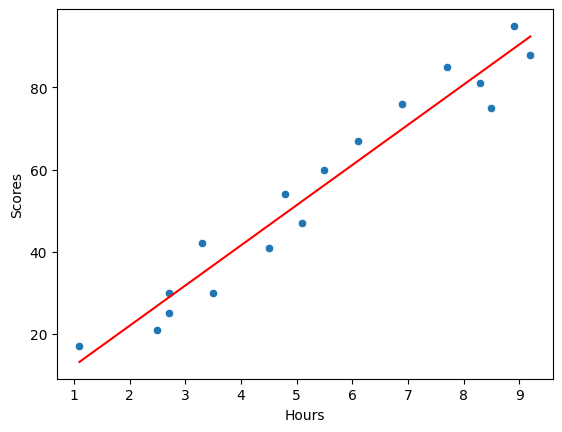

In [268]:
sns.scatterplot(x = X_train.squeeze(), y = y_train)
sns.lineplot(x = X_train.squeeze(), y = lr.predict(X_train_transformed), color = 'red')

In [74]:
# Input feature and target shapes
X_train_transformed.shape, y_train.shape

((17, 1), (17,))

<Axes: xlabel='Hours', ylabel='Scores'>

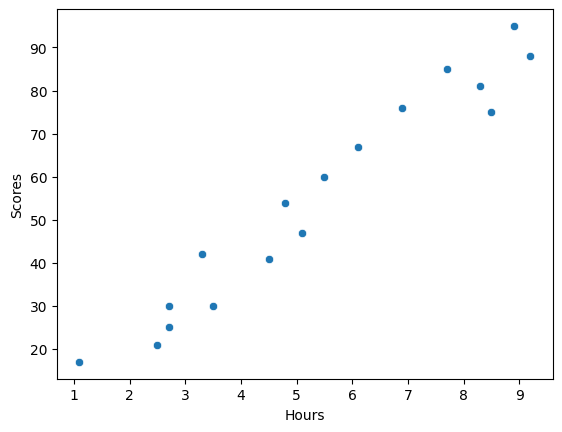

In [75]:
sns.scatterplot(x = X_train.squeeze(), y = y_train)

In [76]:
# Squared Error
def se(X, y, w, b):
  y_hat = w*X.squeeze() + b
  sqerr = ((y - y_hat)**2)
  ssqer = sqerr.sum()
  return ssqer

In [77]:
# Gradient - 2*(y - y_pred)*(-w*X)
def grad_w(X, y, w, b):
  y_pred = w*X.squeeze() + b
  grad = -2*sum(X.squeeze()*(y - y_pred))
  return grad

In [78]:
# Gradient - 2*(y - y_pred)*(-1)
def grad_b(X, y, w, b):
  y_pred = w*X.squeeze() + b
  grad = -2*sum((y - y_pred))
  return grad

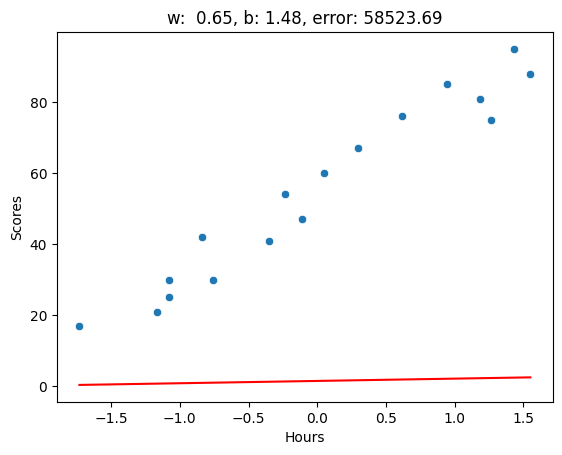

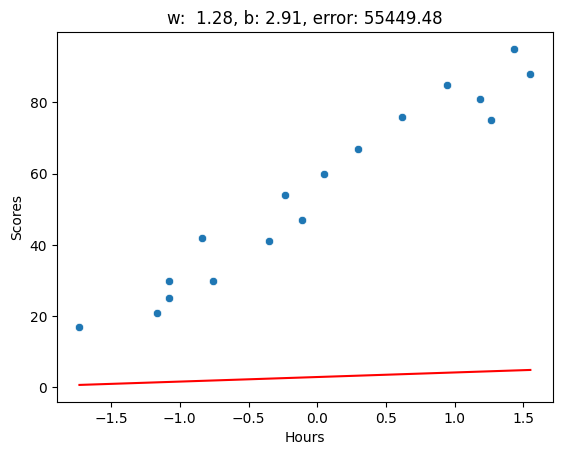

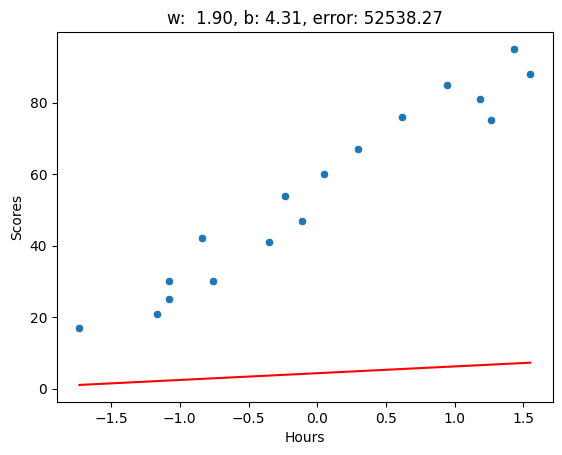

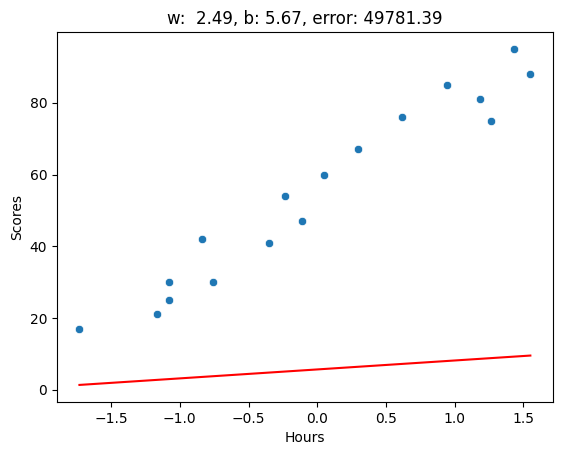

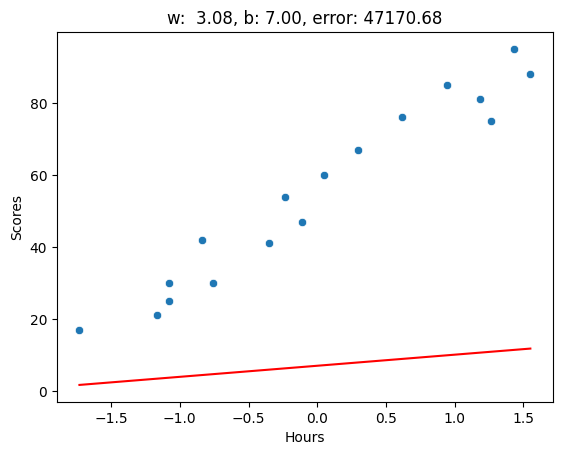

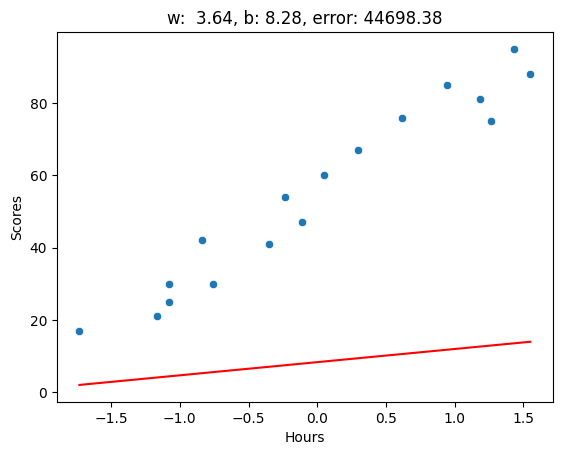

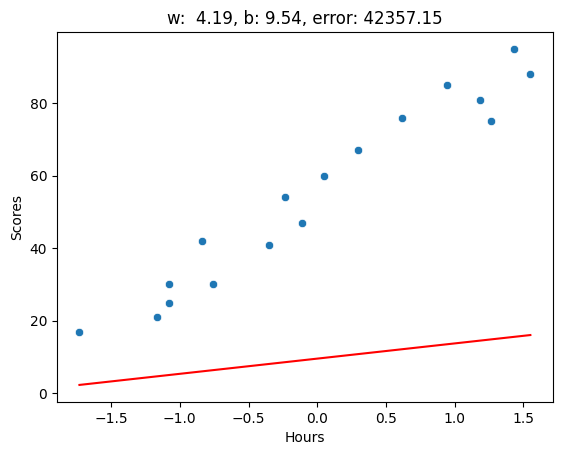

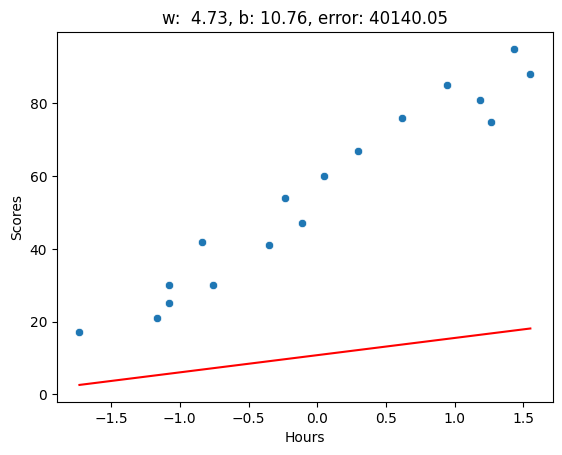

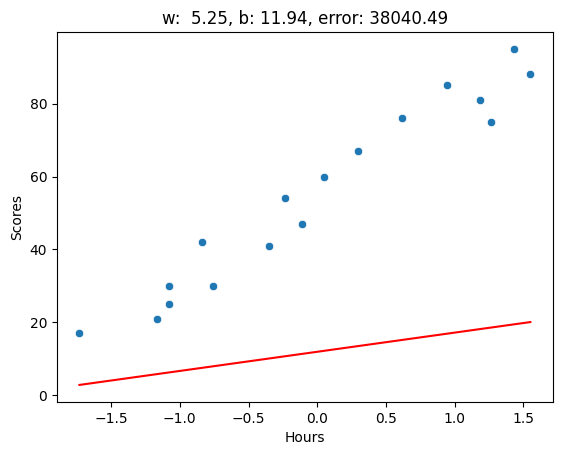

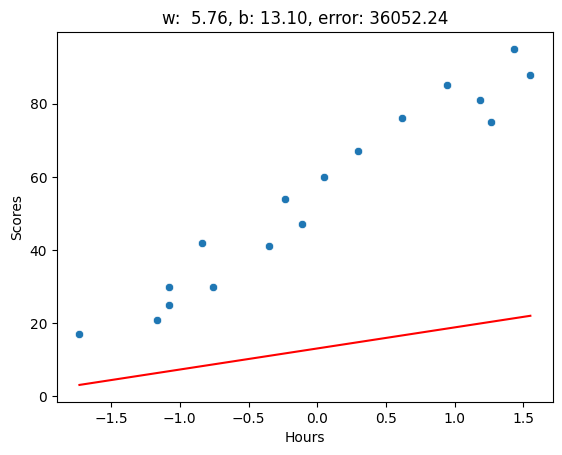

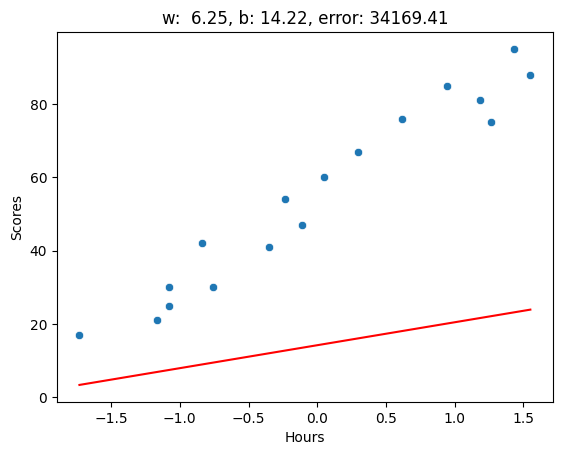

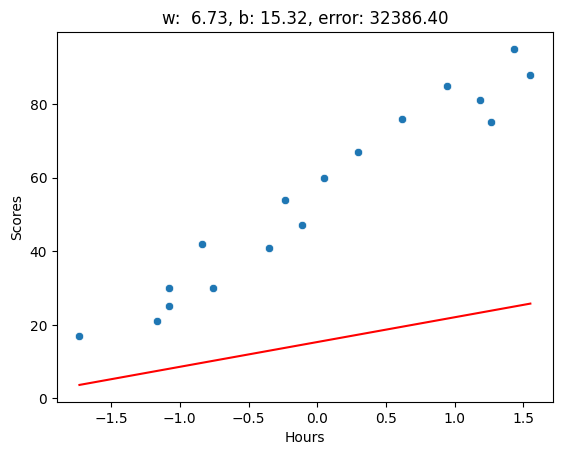

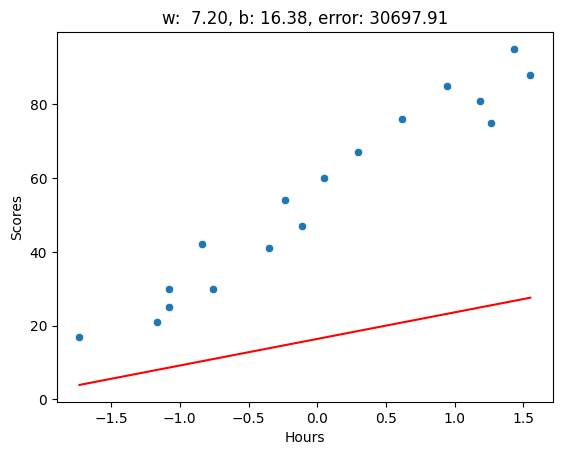

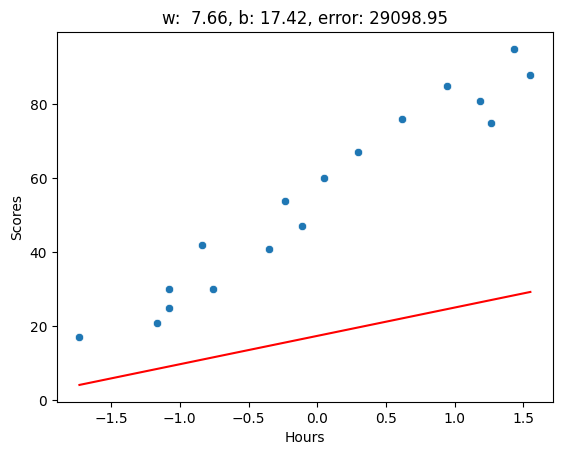

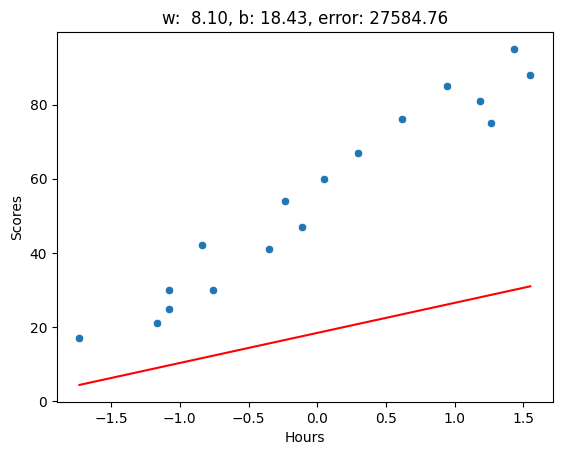

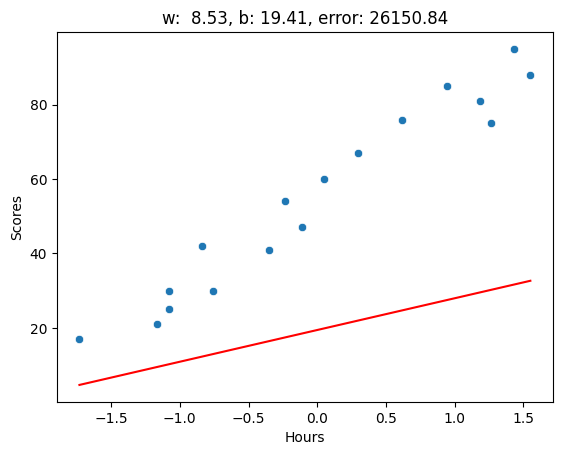

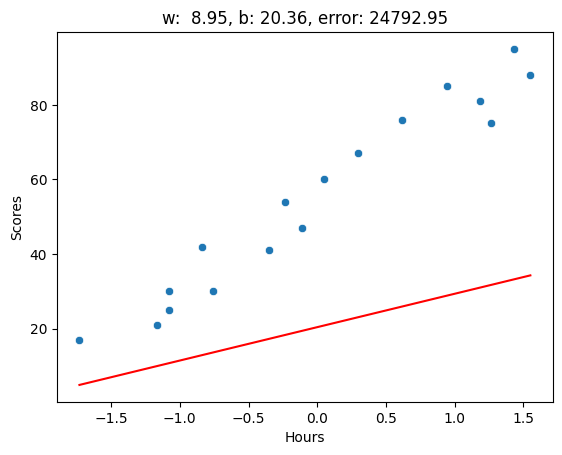

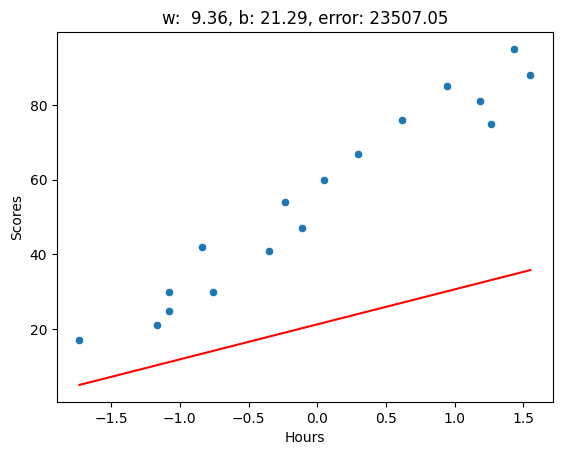

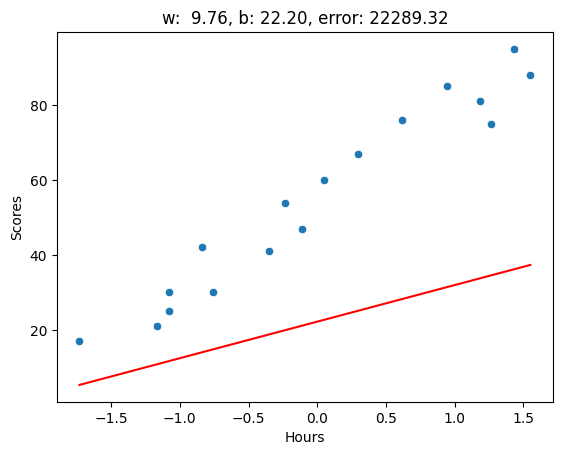

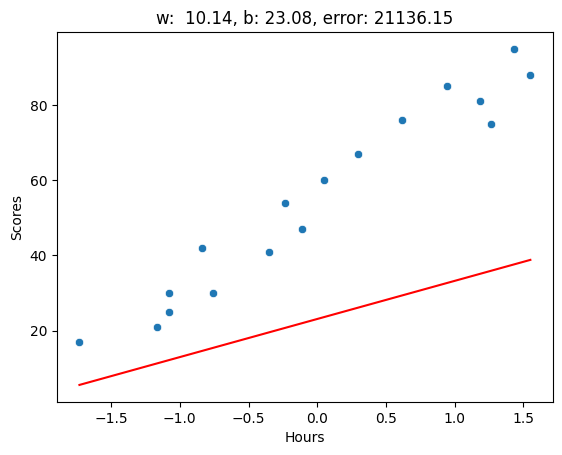

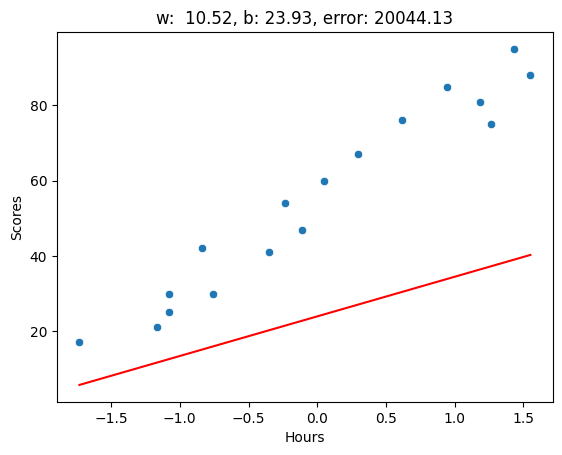

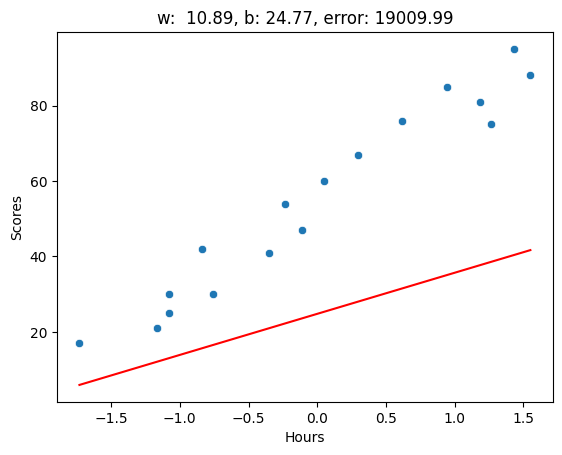

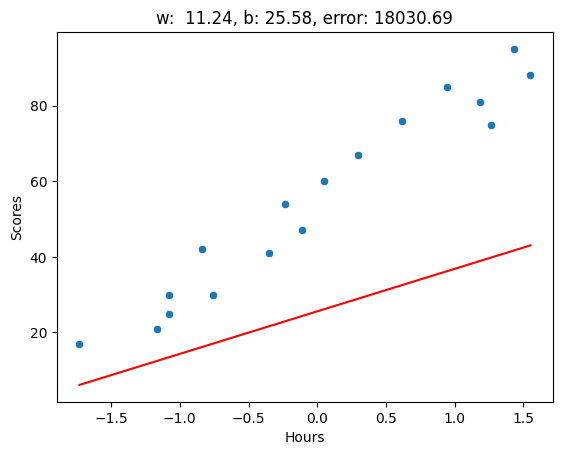

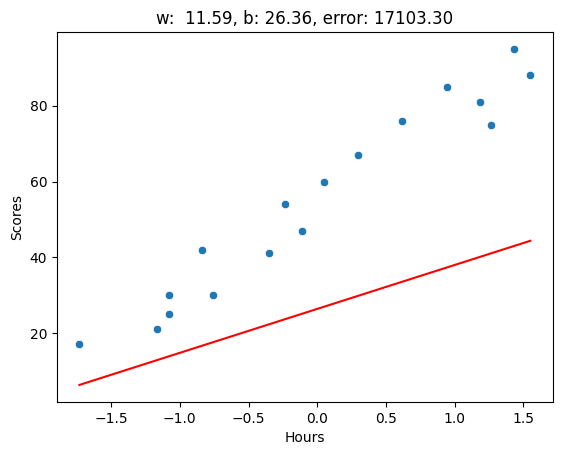

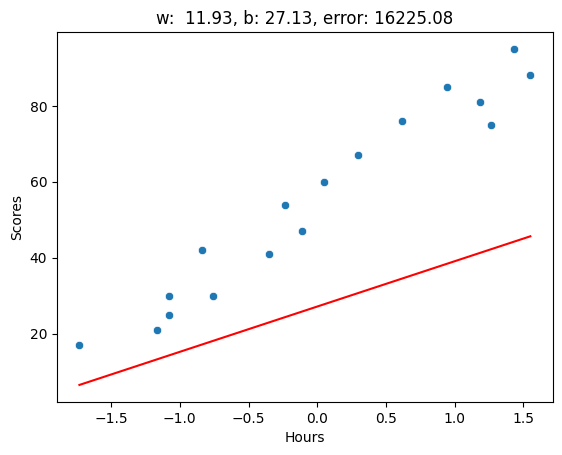

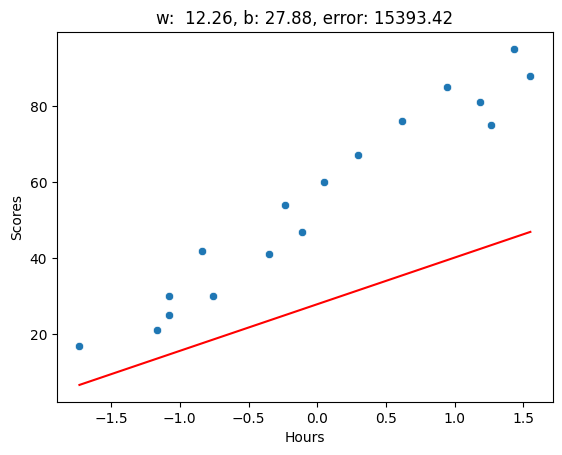

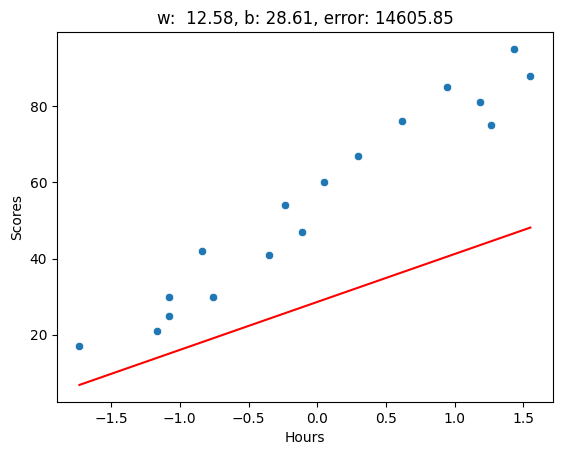

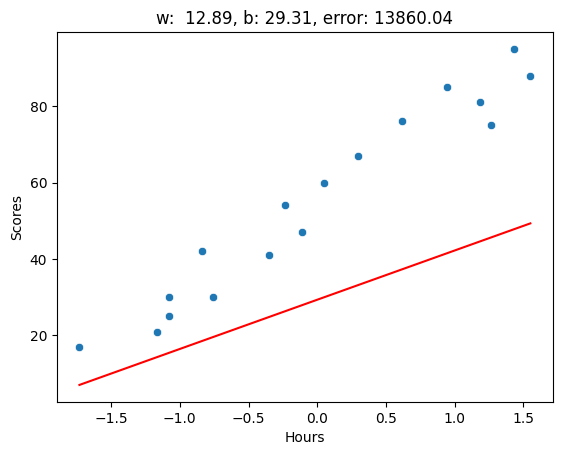

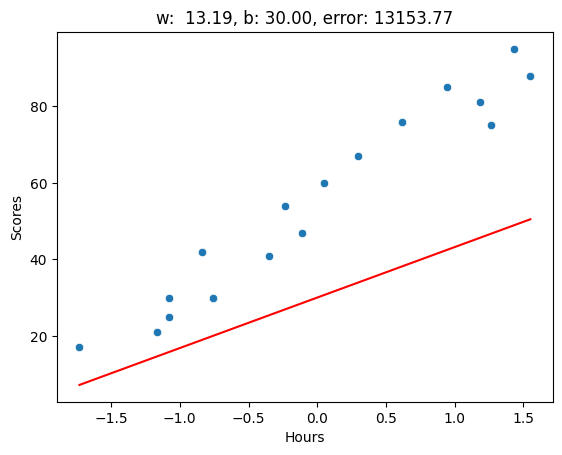

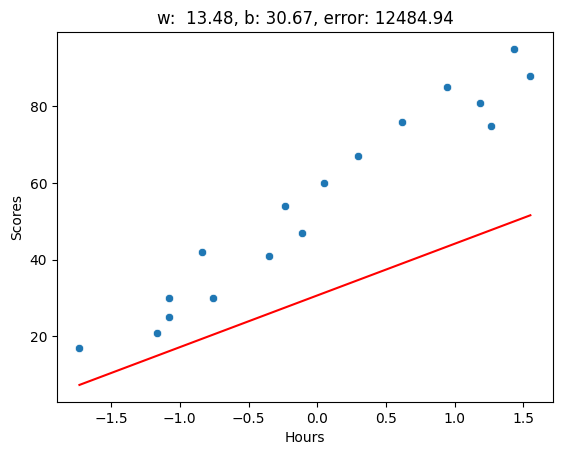

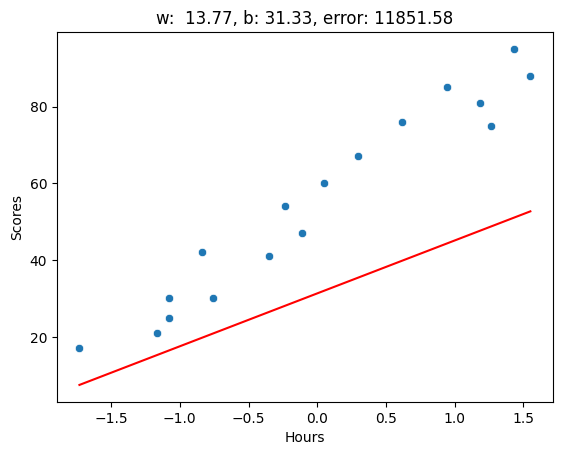

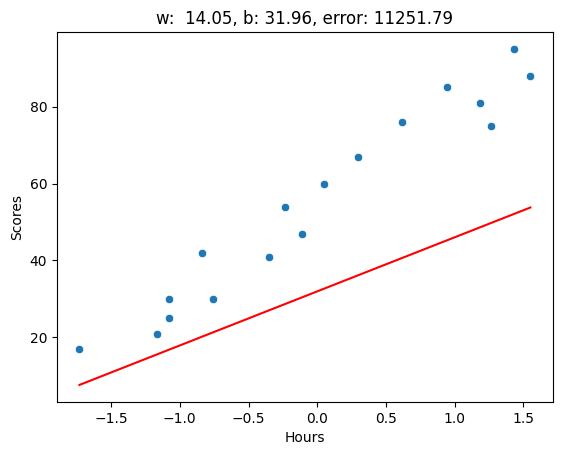

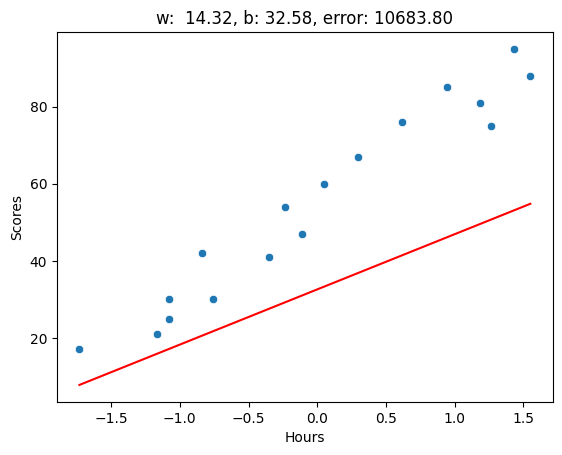

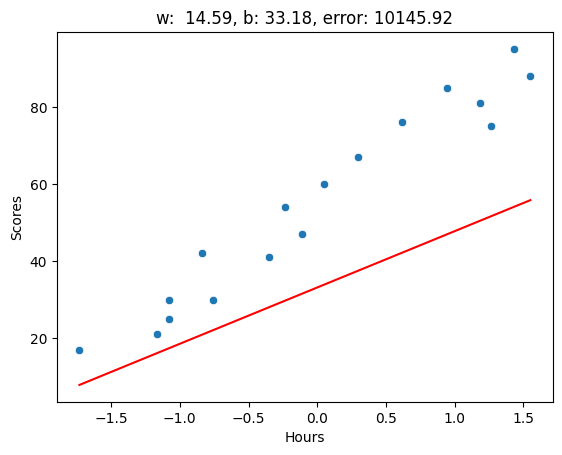

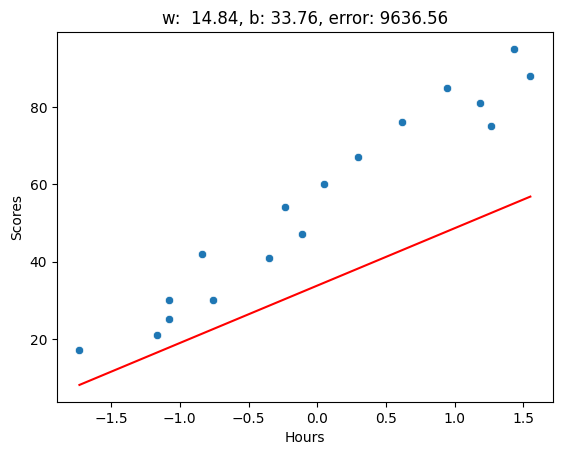

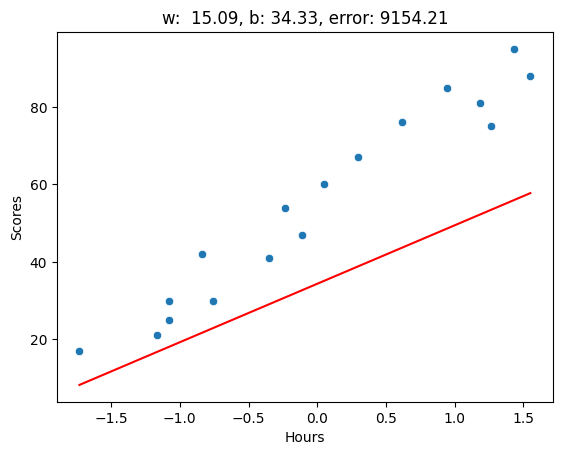

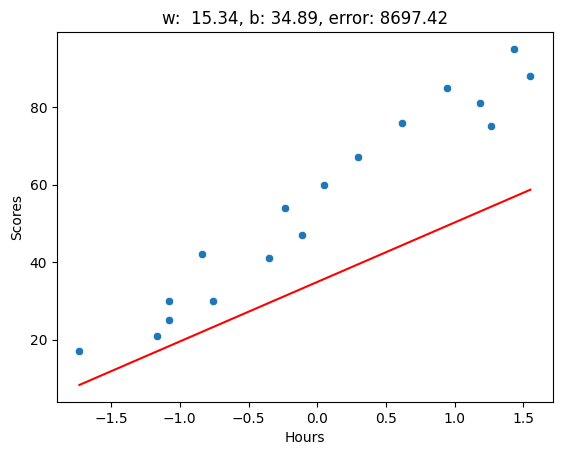

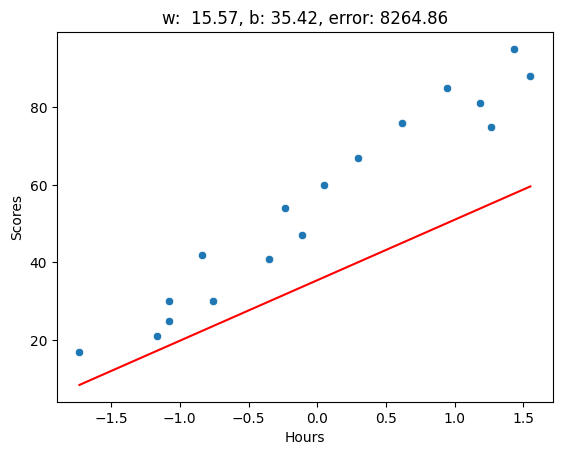

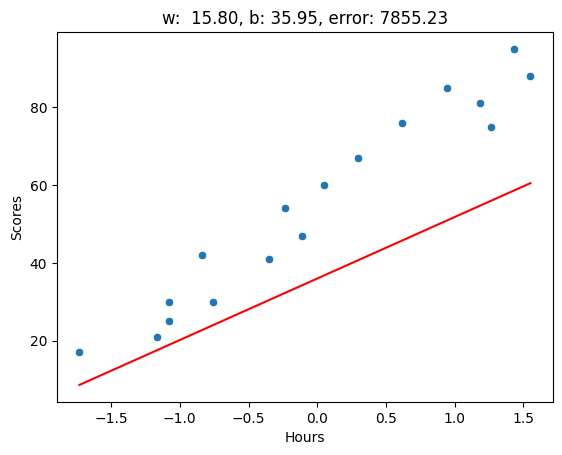

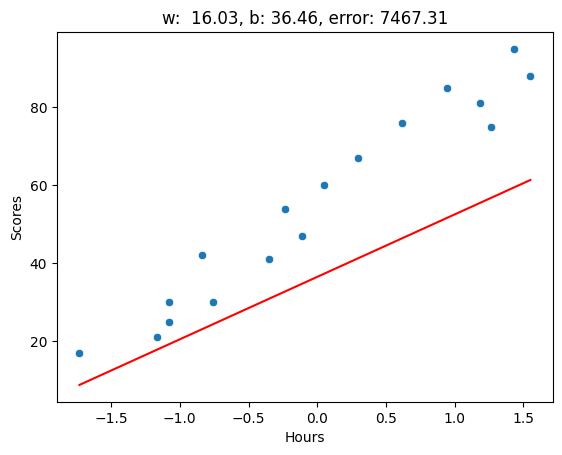

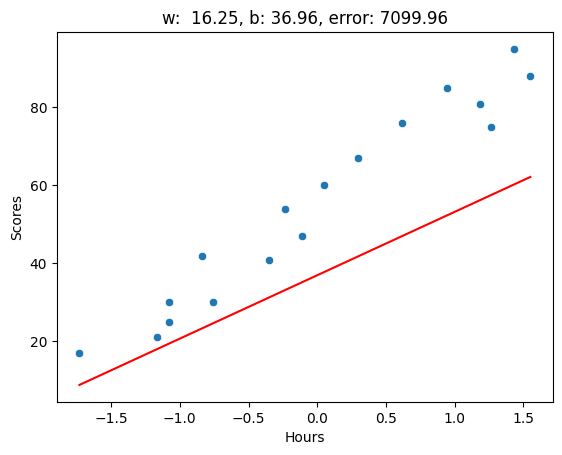

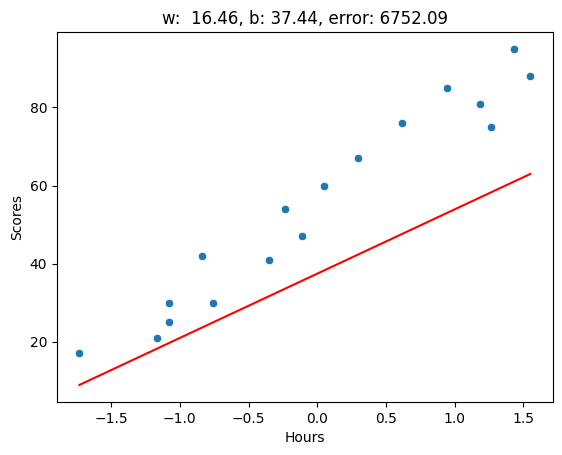

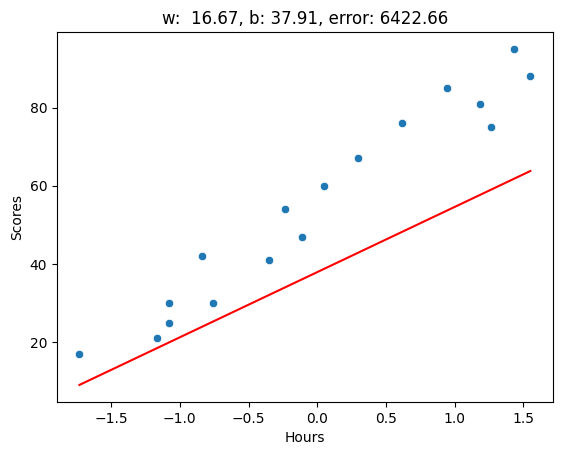

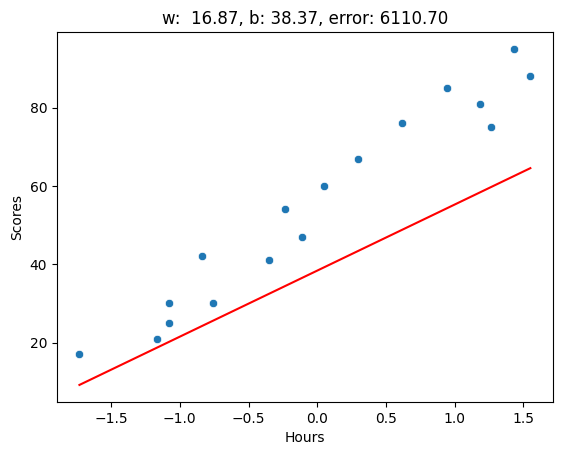

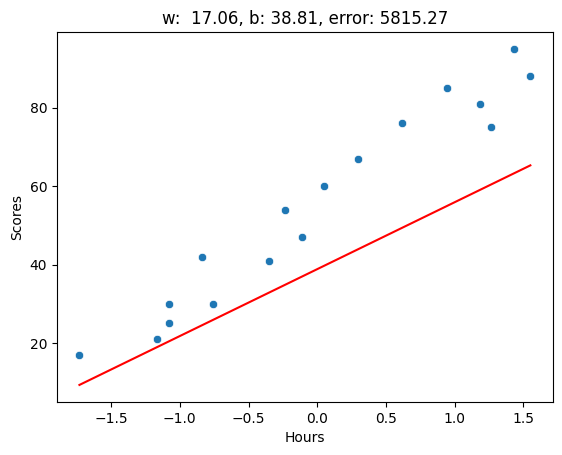

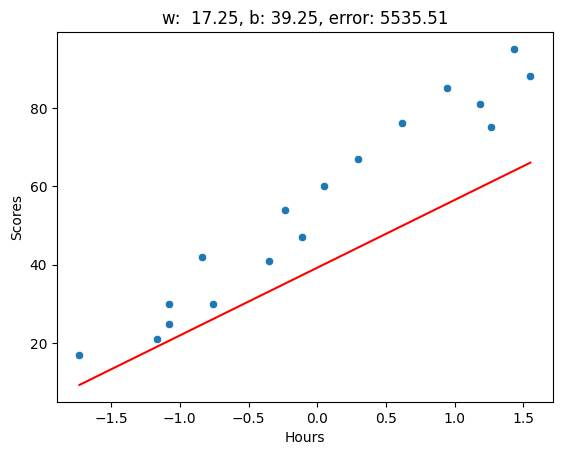

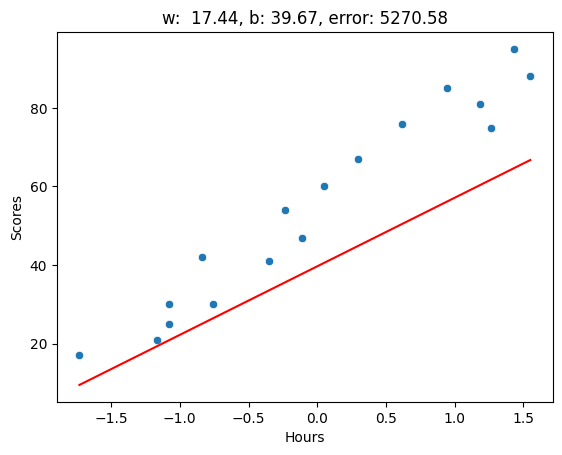

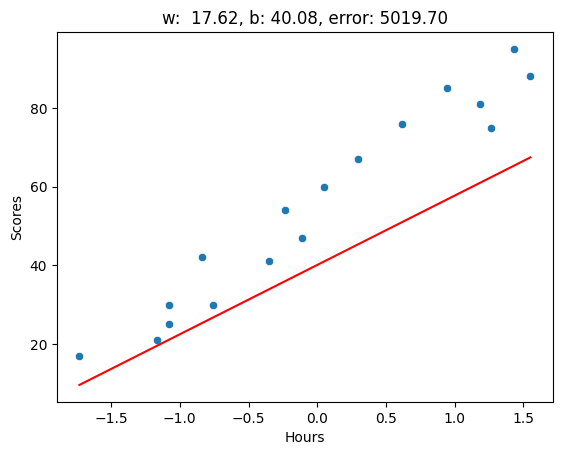

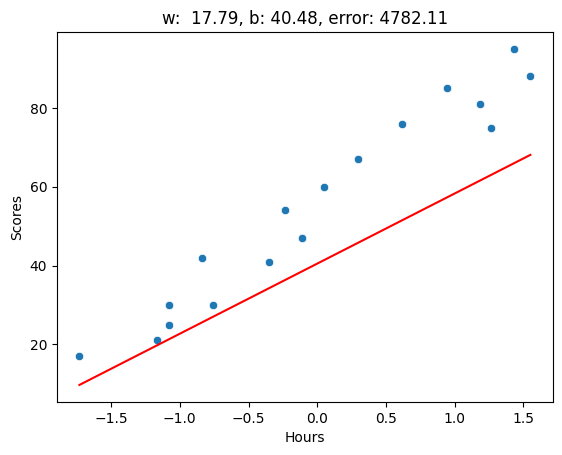

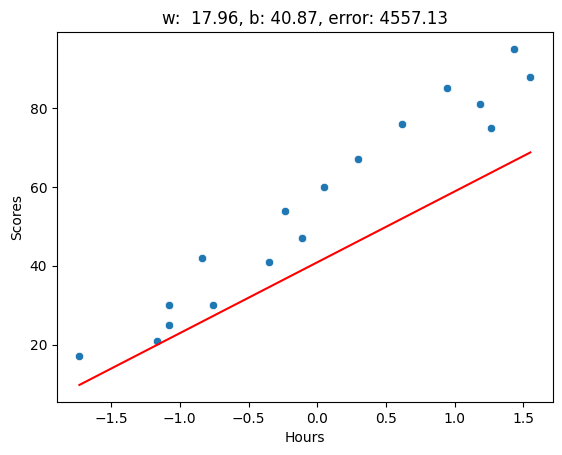

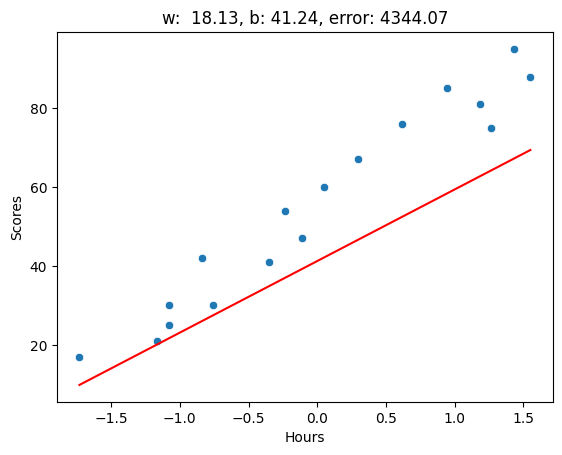

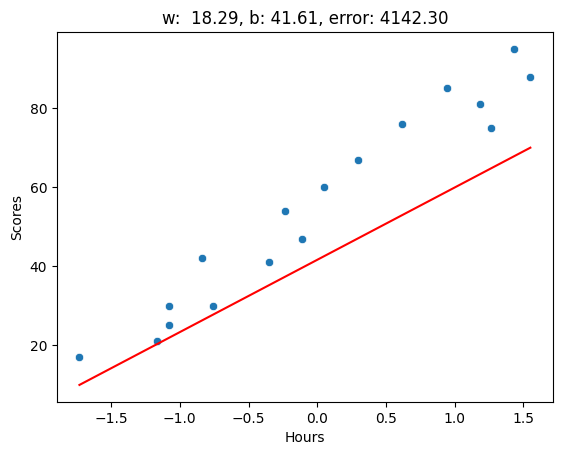

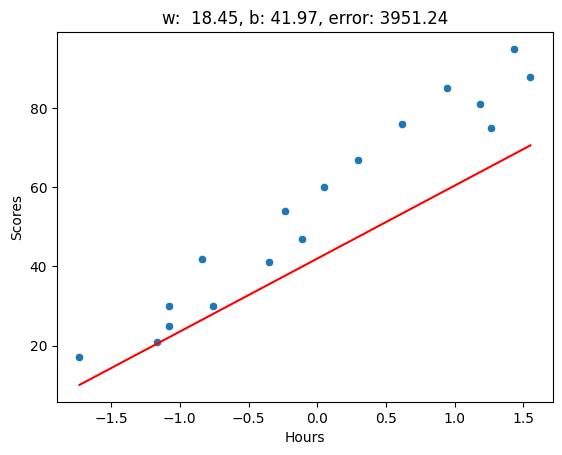

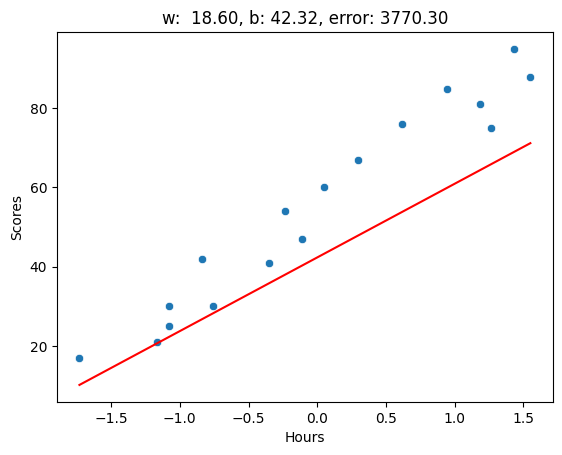

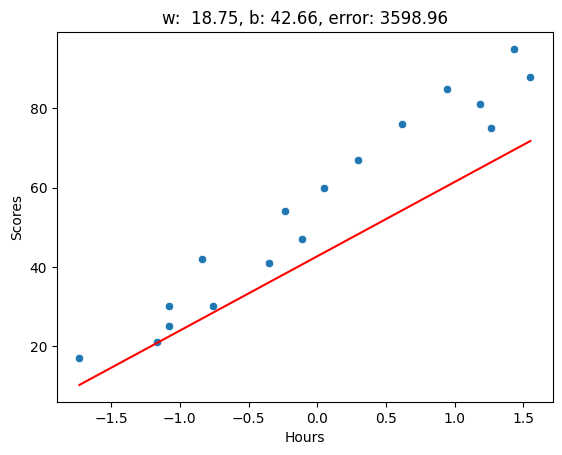

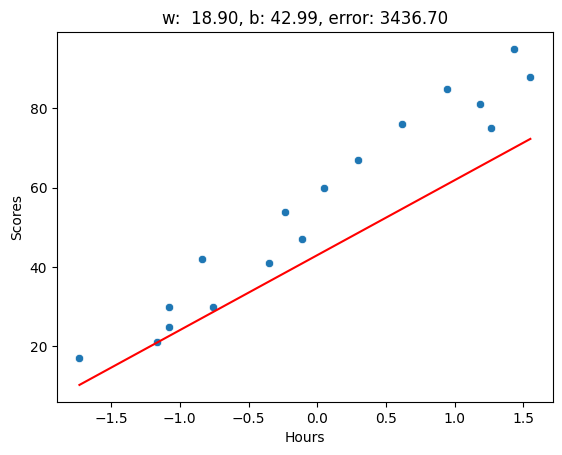

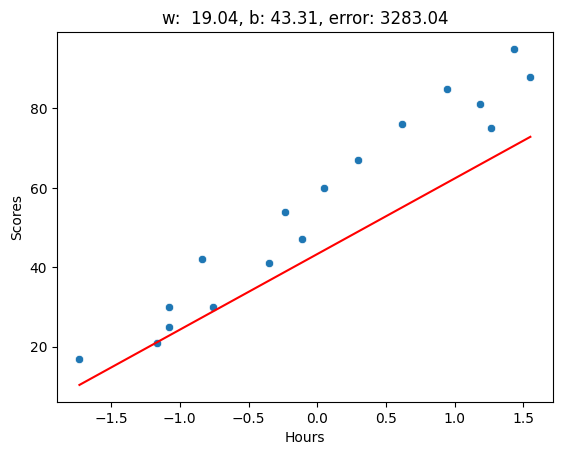

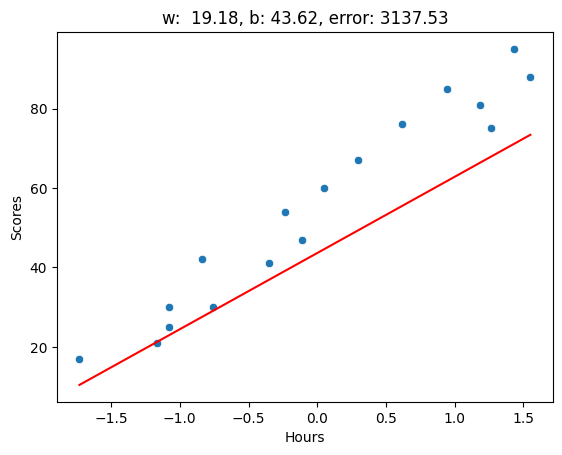

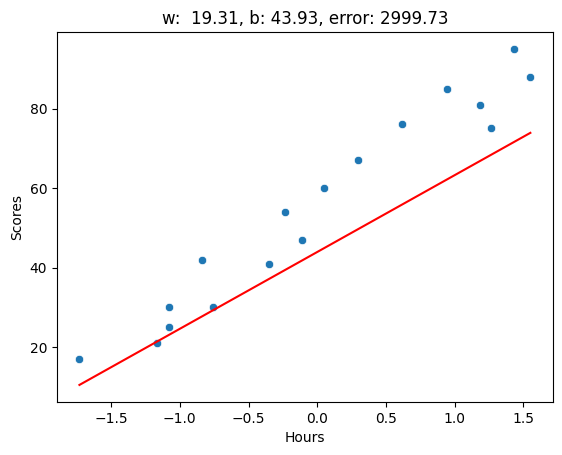

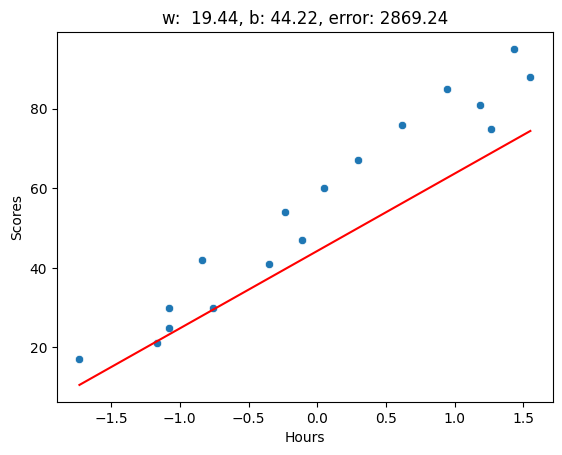

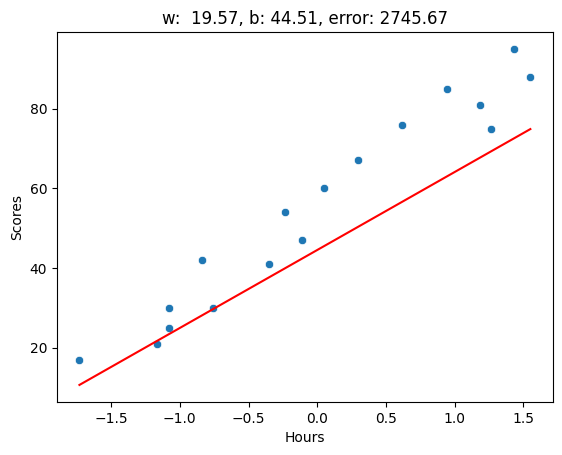

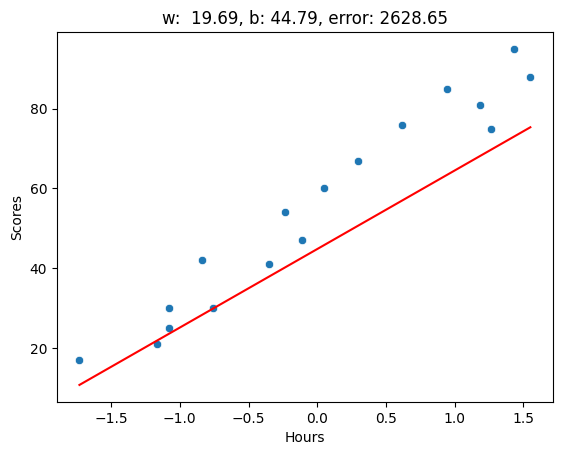

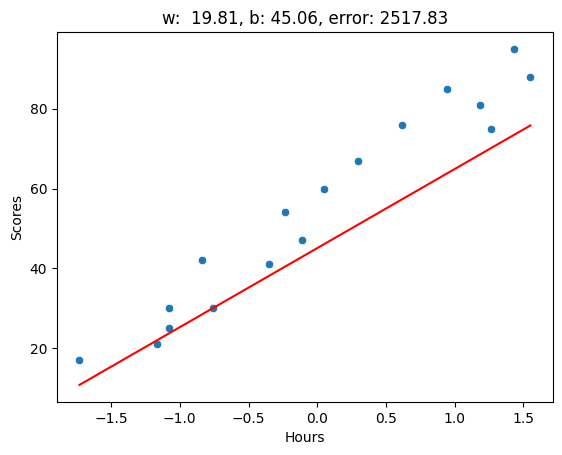

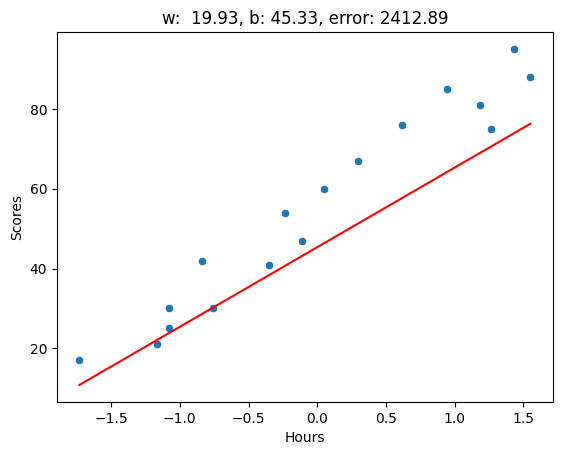

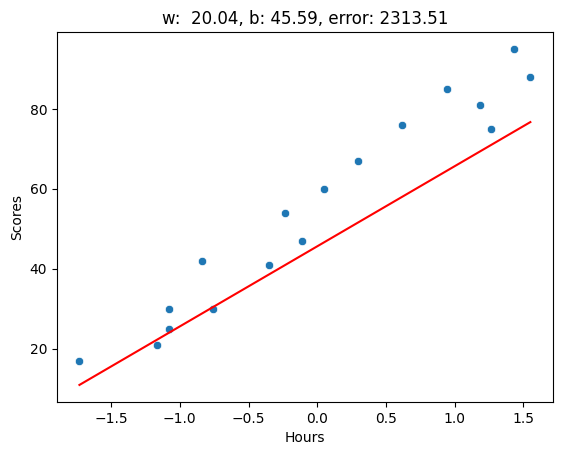

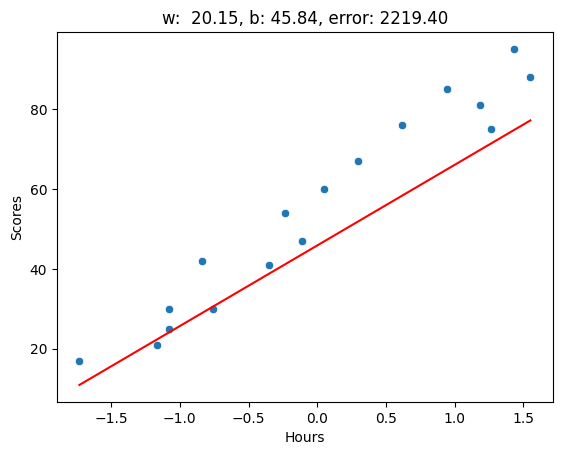

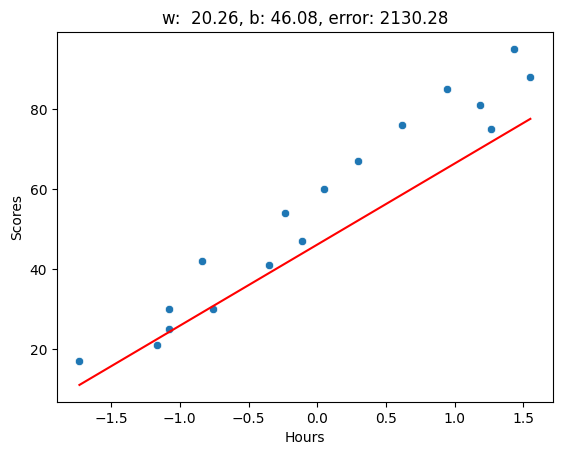

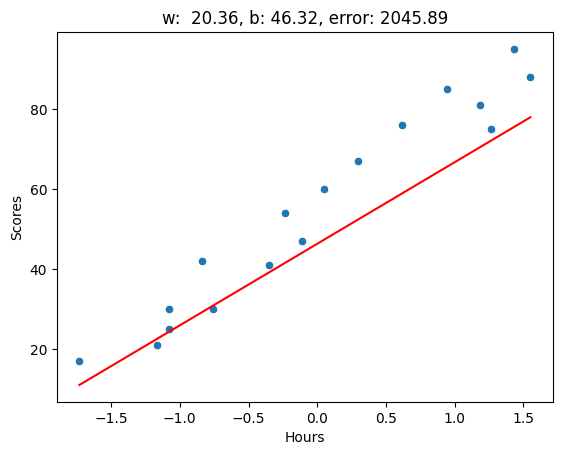

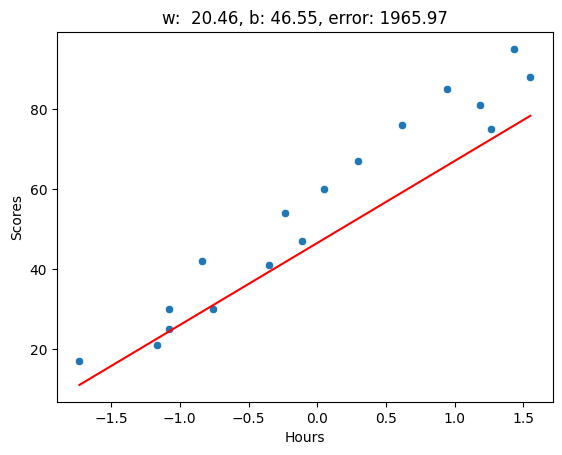

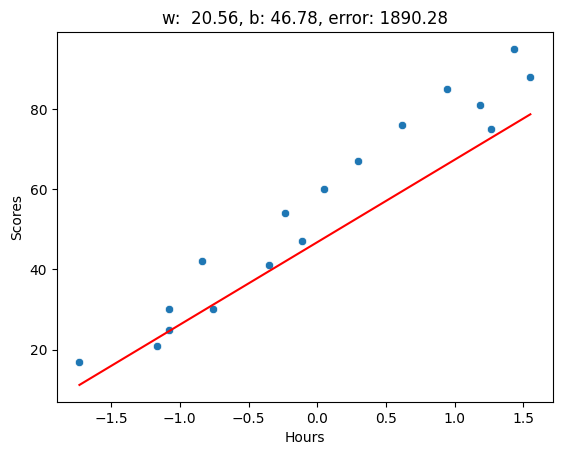

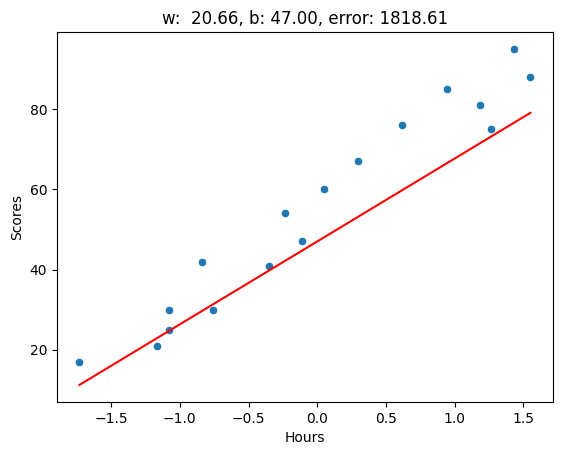

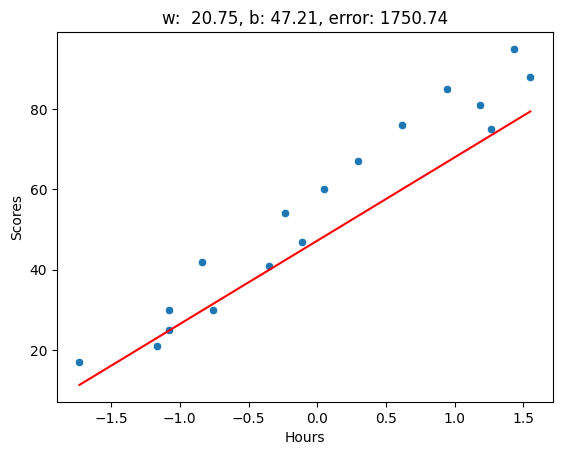

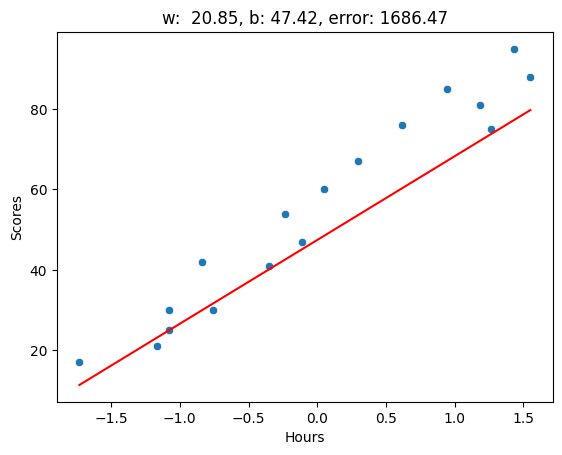

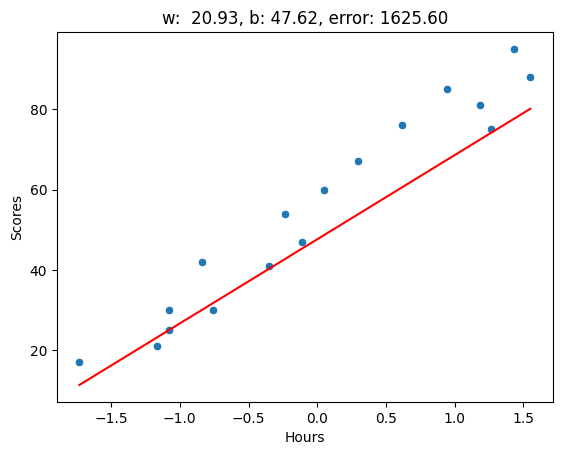

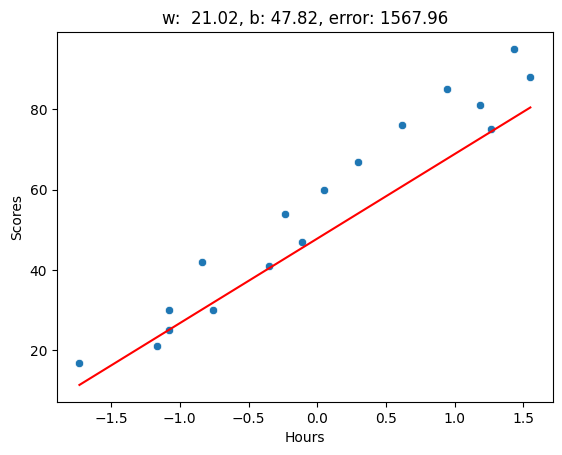

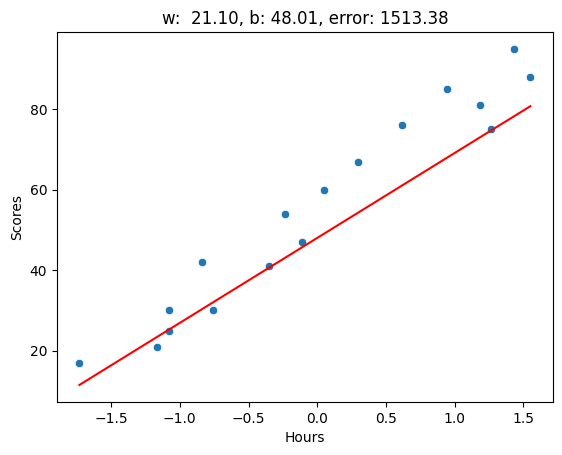

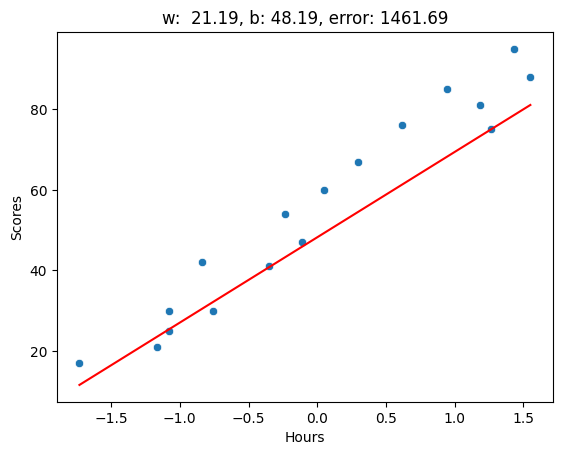

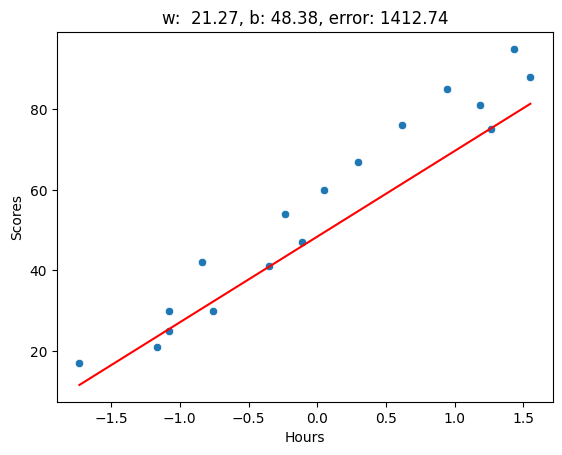

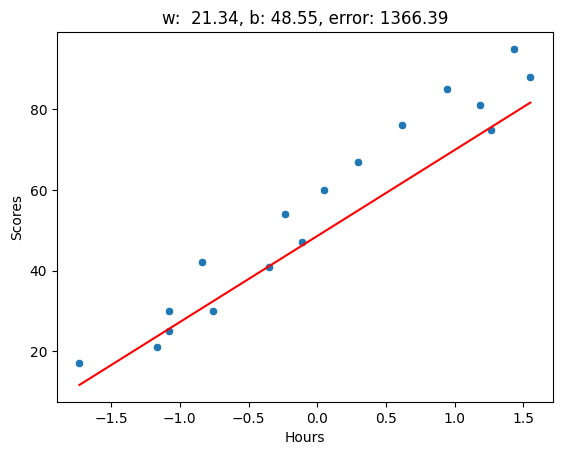

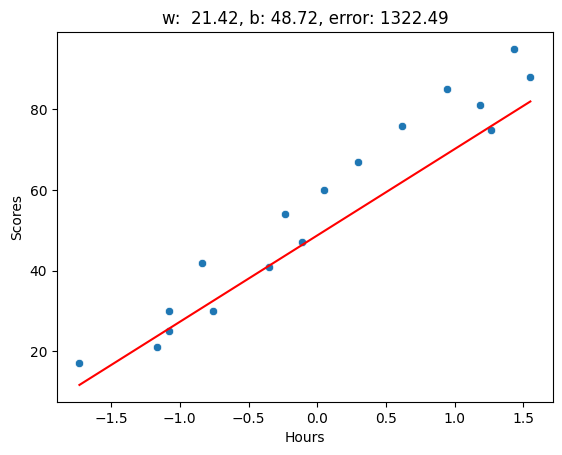

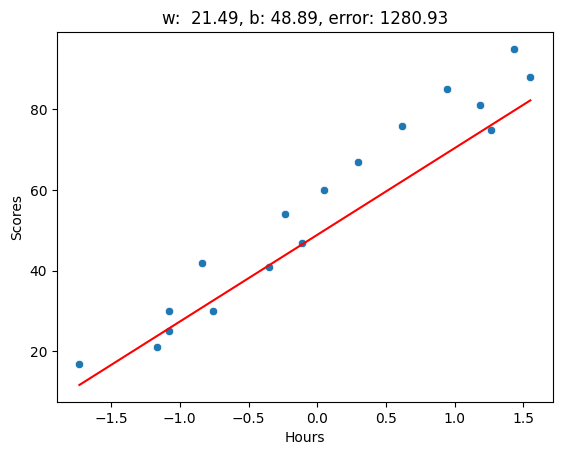

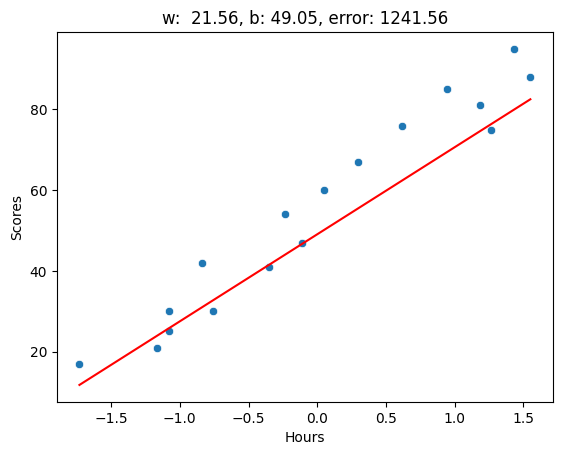

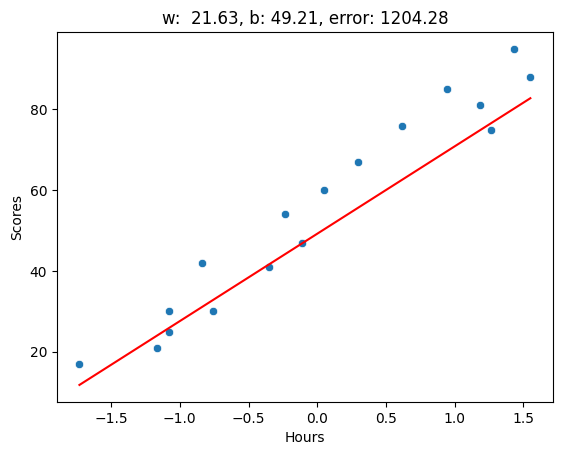

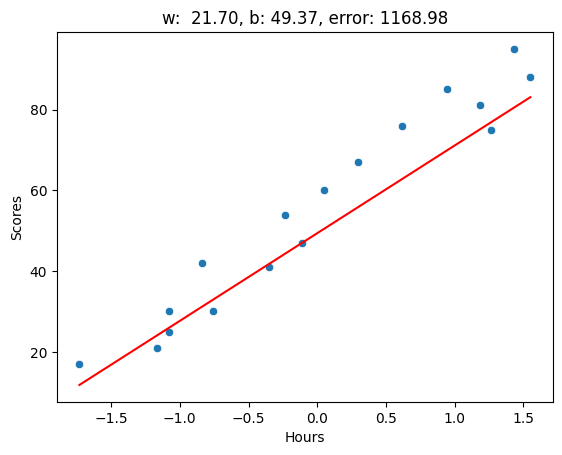

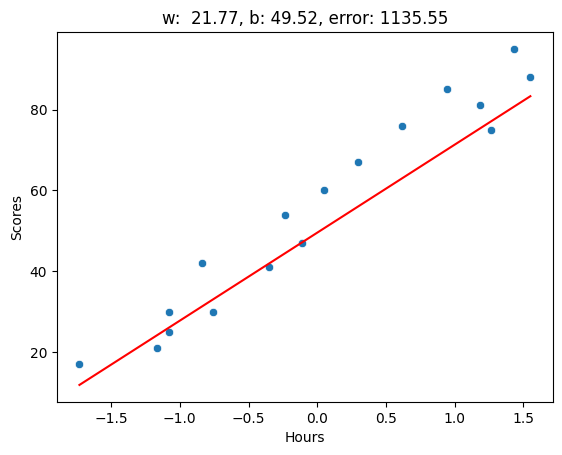

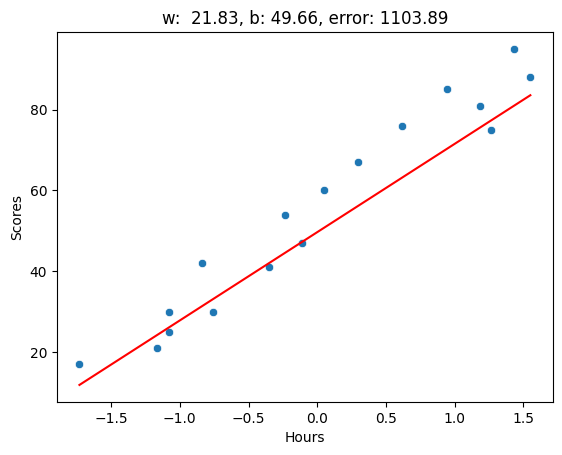

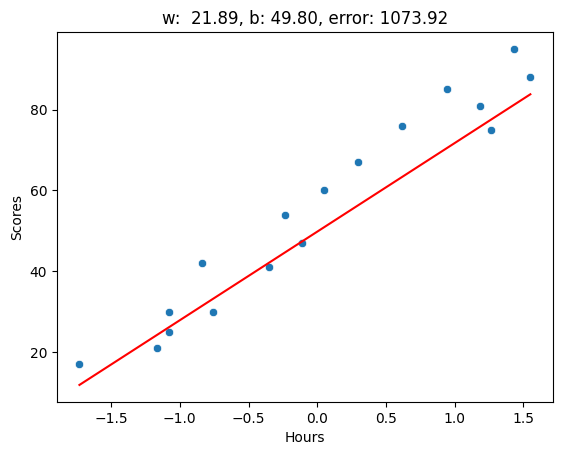

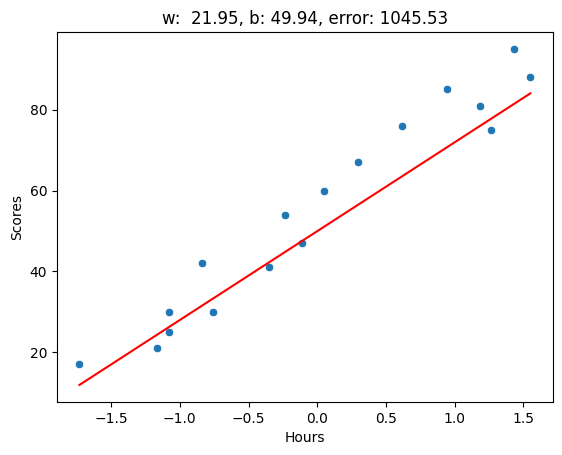

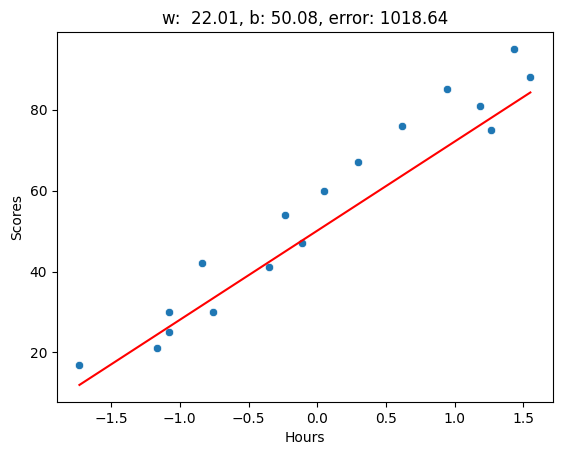

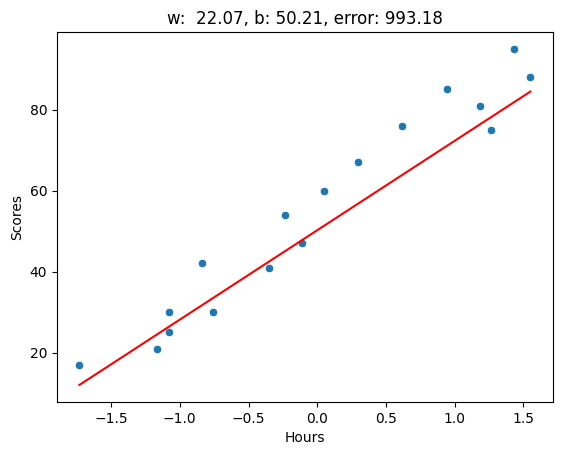

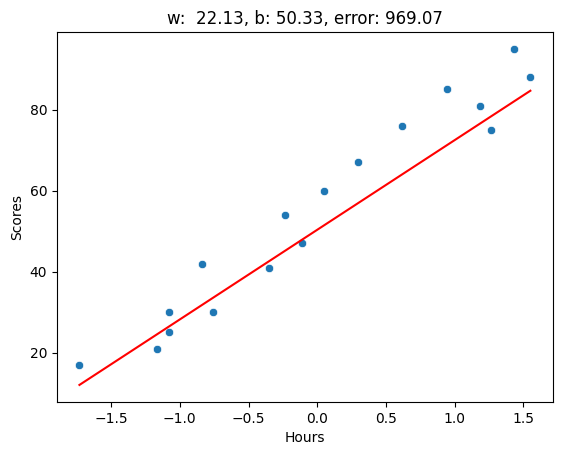

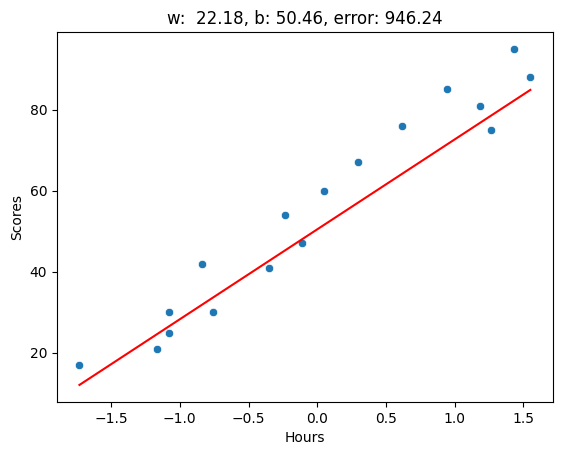

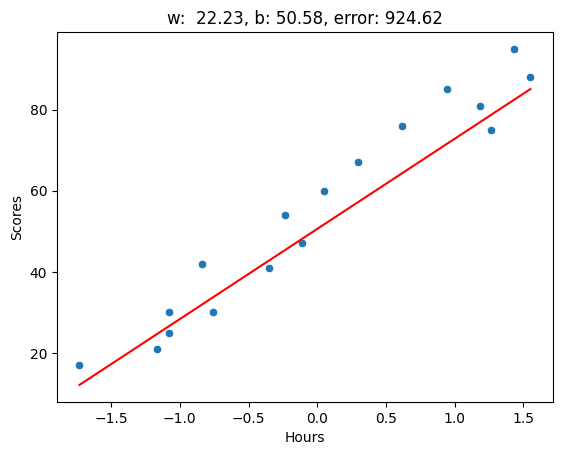

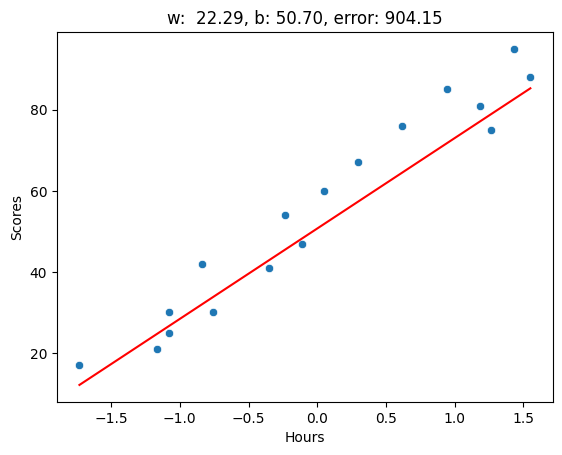

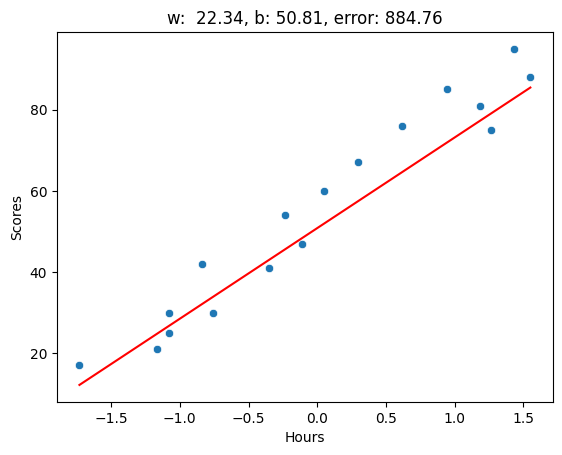

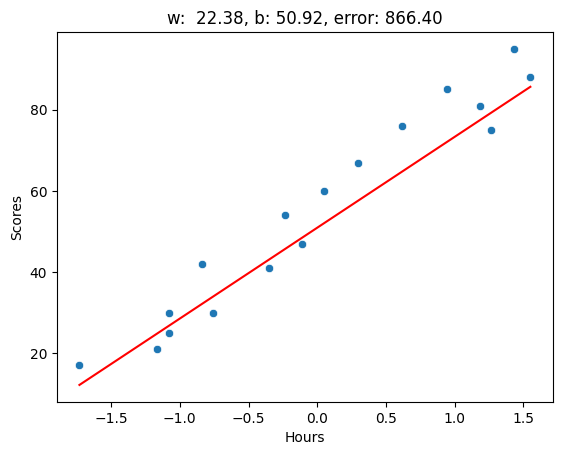

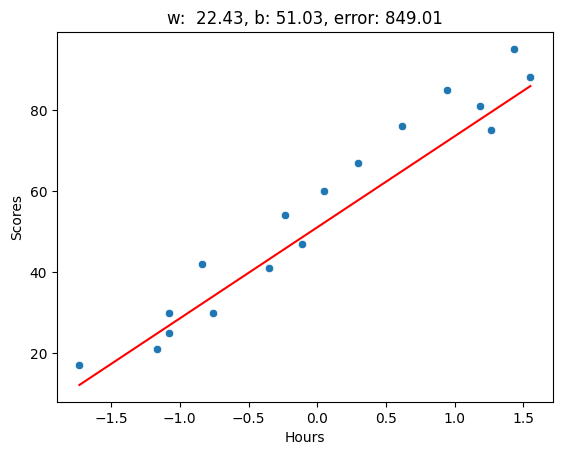

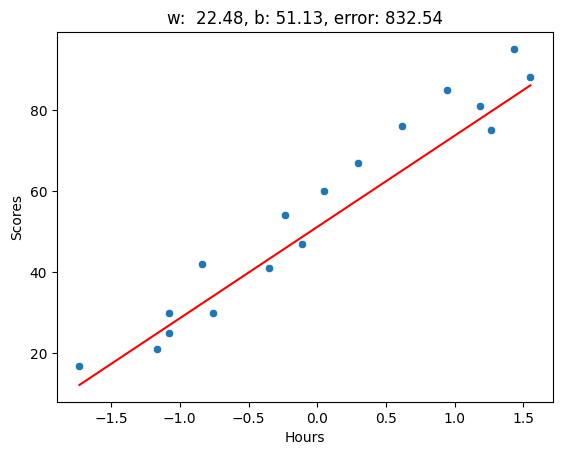

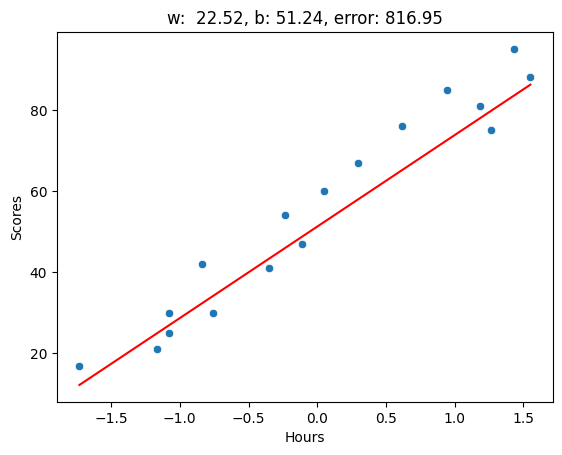

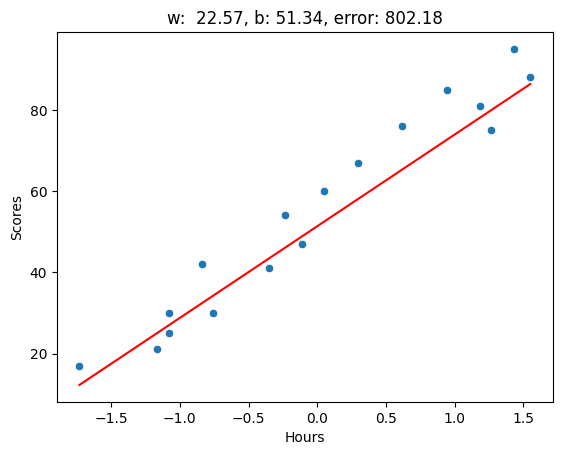

In [79]:
# Gradient Descent
# w_new = w_old - eta*(grad_w/b)
w_hist = []
w, b = 0, 0
eta = 0.00008
n_iter = 1000
iter = 0
while iter < n_iter:
  error = se(X_train_transformed, y_train, w, b)
  gw = grad_w(X_train_transformed, y_train, w, b)
  gb = grad_b(X_train_transformed, y_train, w, b)
  w = w - (eta*gw)
  b = b - (eta*gb)
  error_new = se(X_train_transformed, y_train, w, b)
  w_hist.append((w, b, error_new))
  iter += 1
  # Plot
  if iter%10 == 0:
    y_hat = w*X_train_transformed.squeeze() + b
    sns.scatterplot(x = X_train_transformed.squeeze(), y = y_train)
    sns.lineplot(x = X_train_transformed.squeeze(), y = y_hat, color = 'r')
    plt.title(f'w: {w: .2f}, b: {b:.2f}, error: {error_new:.2f}')
    plt.show()
  # if error_new > error:
  #   iter = n_iter


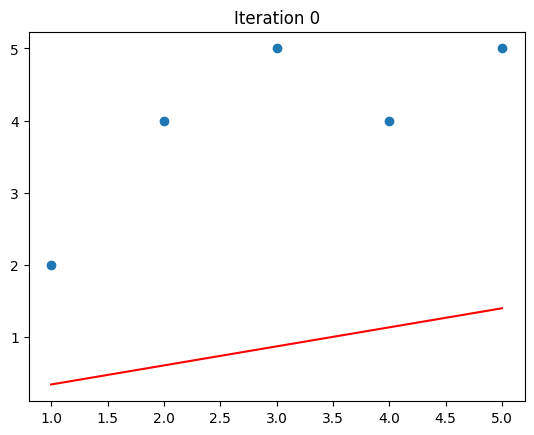

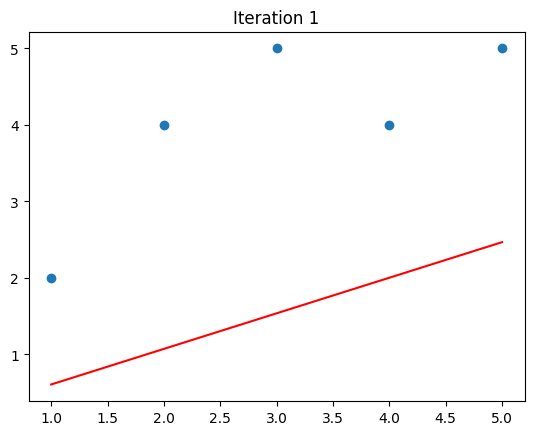

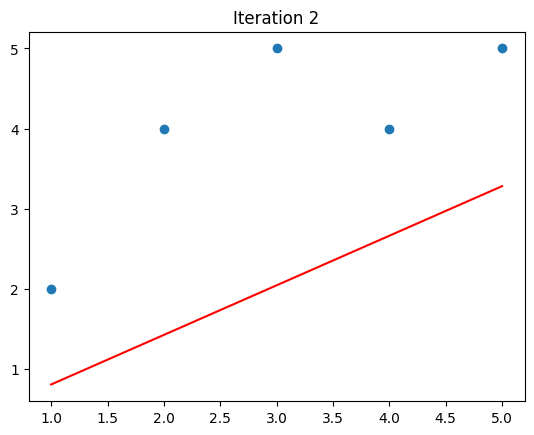

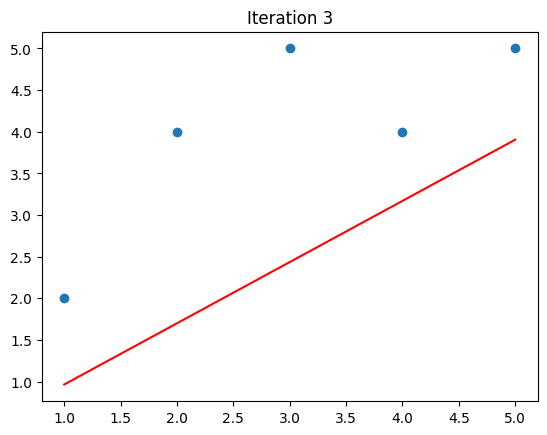

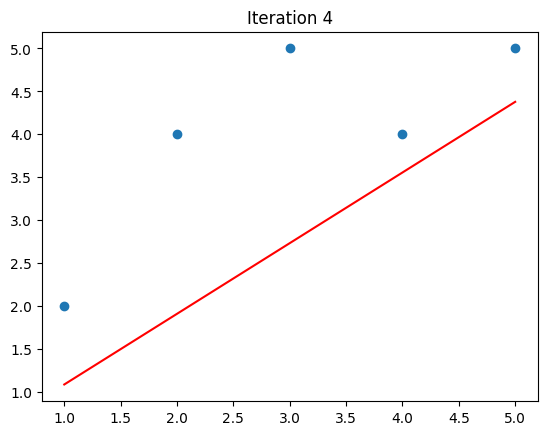

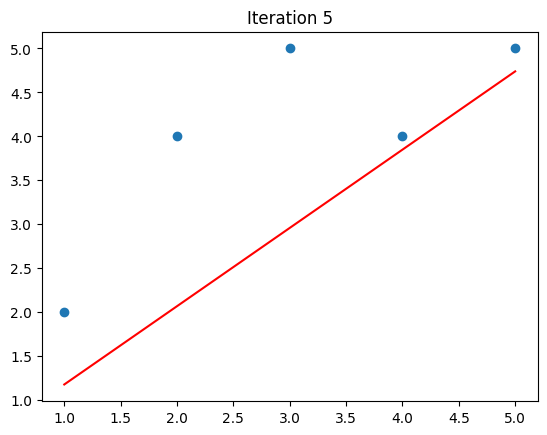

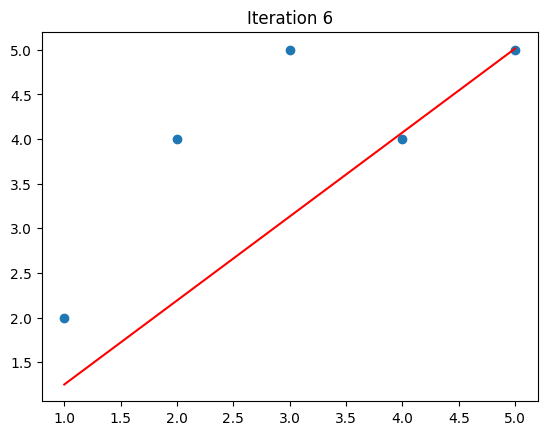

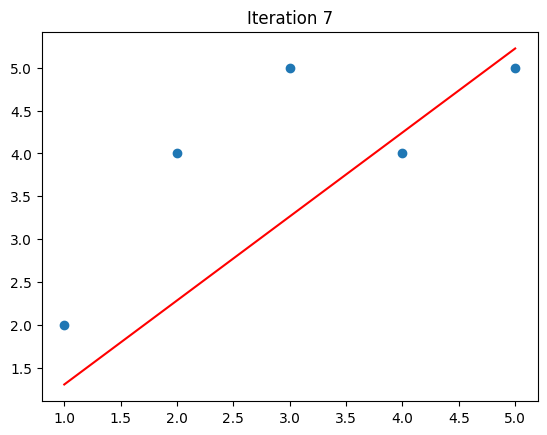

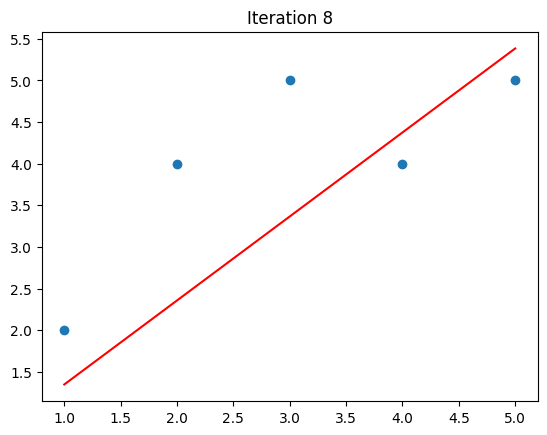

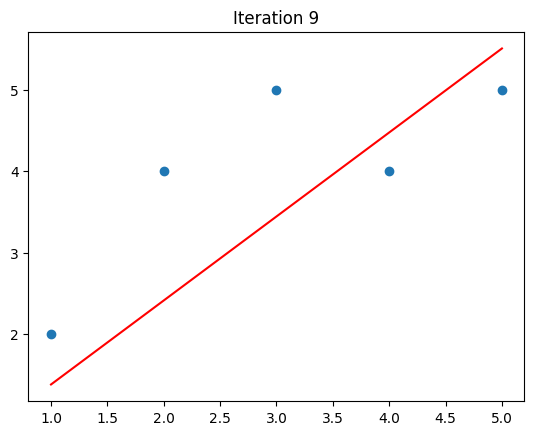

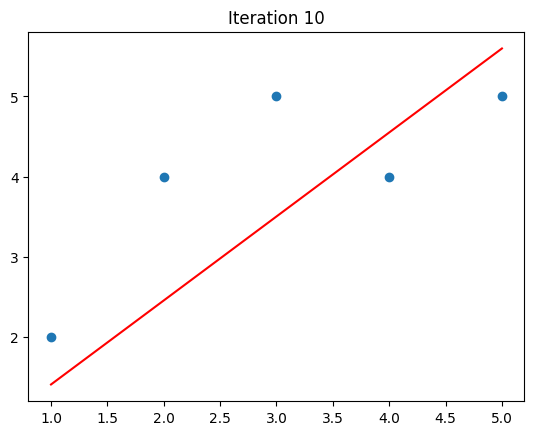

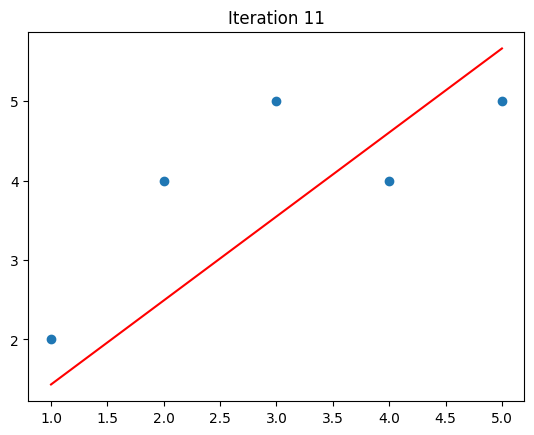

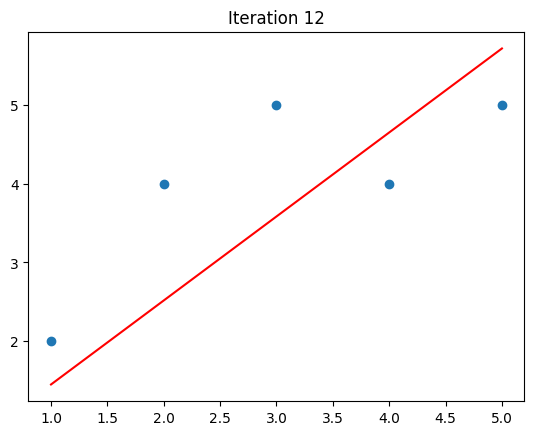

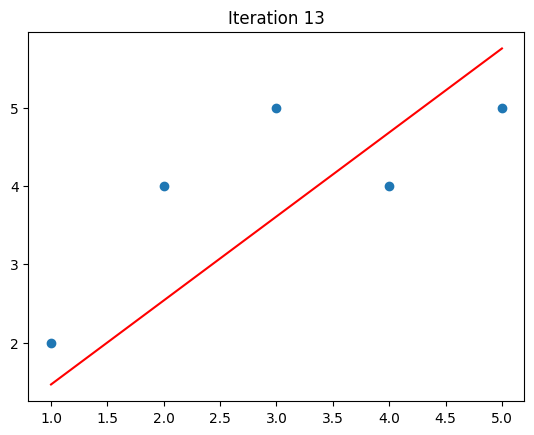

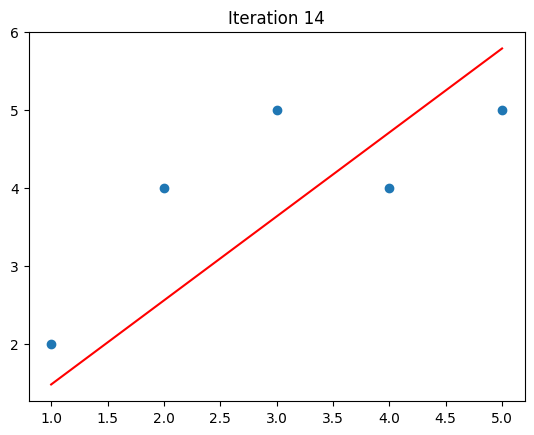

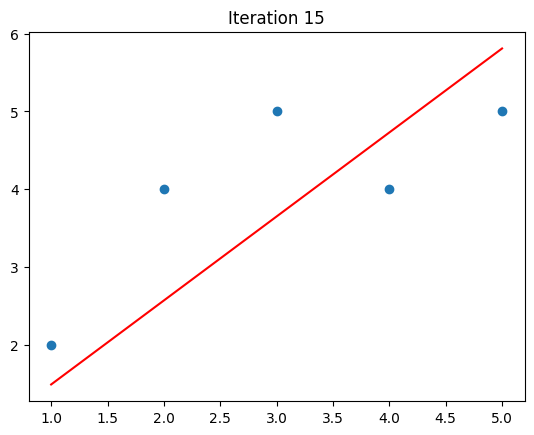

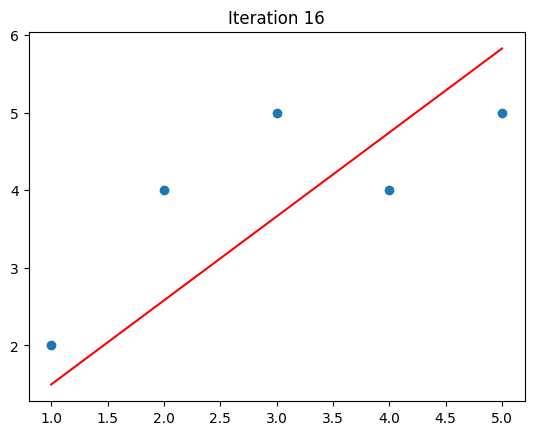

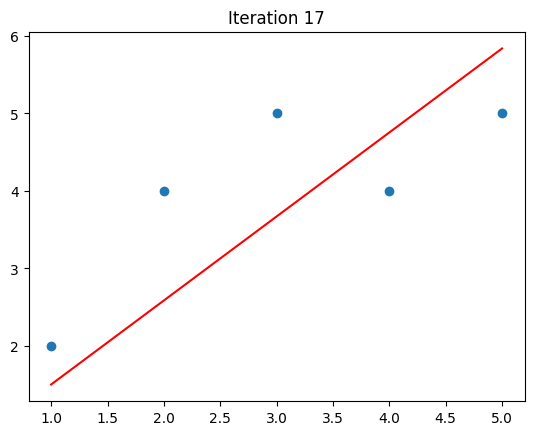

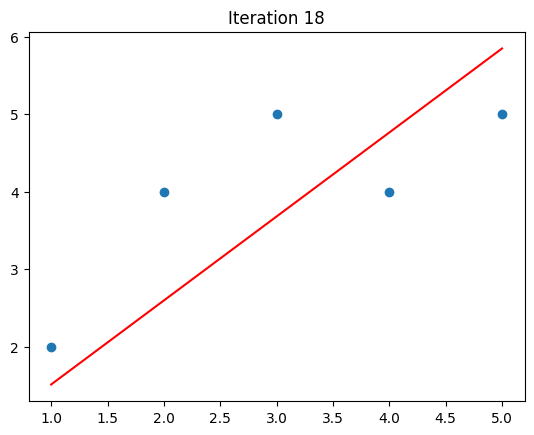

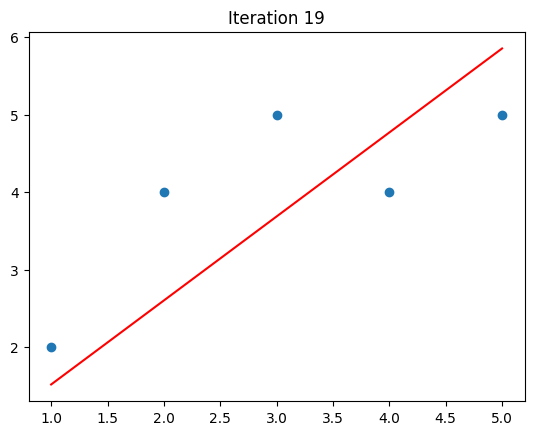

<Figure size 640x480 with 0 Axes>

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# dataset
X = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])

m = 0
b = 0
lr = 0.01

for i in range(20):
    
    y_pred = m*X + b
    
    dm = (-2/len(X))*np.sum(X*(y-y_pred))
    db = (-2/len(X))*np.sum(y-y_pred)
    
    m -= lr*dm
    b -= lr*db
    
    plt.scatter(X,y)
    plt.plot(X, m*X+b, color='red')
    plt.title(f"Iteration {i}")
    plt.pause(0.3)
    plt.clf()

plt.show()

## How One Outlier Can Destroy Linear Regression
- see one bad point can completely change the regression line.

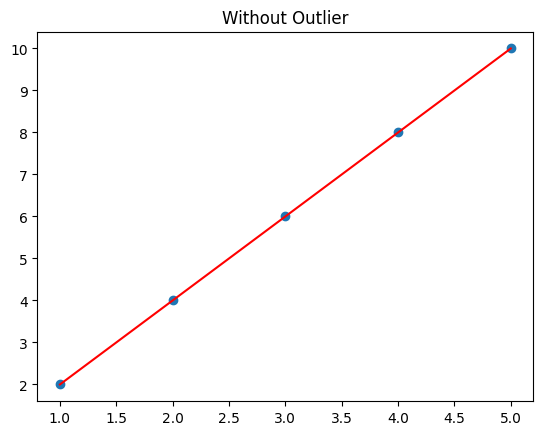

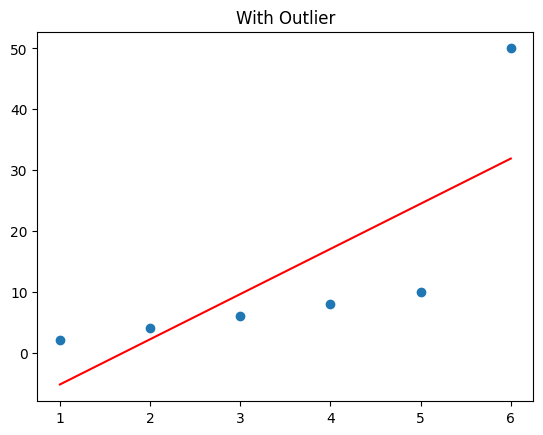

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1,2,3,4,5]).reshape(-1,1)
y = np.array([2,4,6,8,10])

model = LinearRegression()
model.fit(X,y)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')
plt.title("Without Outlier")
plt.show()

# add outlier
X2 = np.append(X,[[6]],axis=0)
y2 = np.append(y,[50])

model.fit(X2,y2)

plt.scatter(X2,y2)
plt.plot(X2,model.predict(X2),color='red')
plt.title("With Outlier")
plt.show()

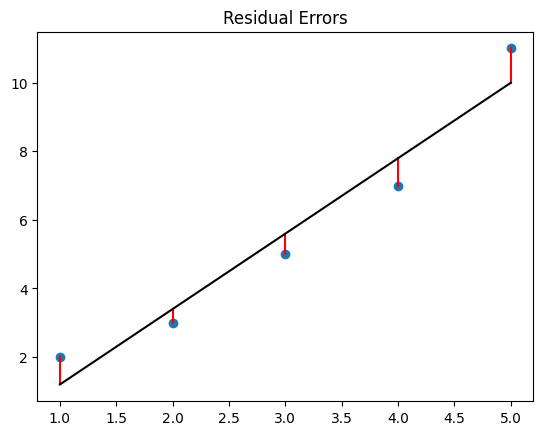

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1,2,3,4,5]).reshape(-1,1)
y = np.array([2,3,5,7,11])

model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)

plt.scatter(X,y)

for i in range(len(X)):
    plt.plot([X[i],X[i]],[y[i],y_pred[i]],color='red')

plt.plot(X,y_pred,color='black')
plt.title("Residual Errors")
plt.show()

## Linear vs Polynomial Regression

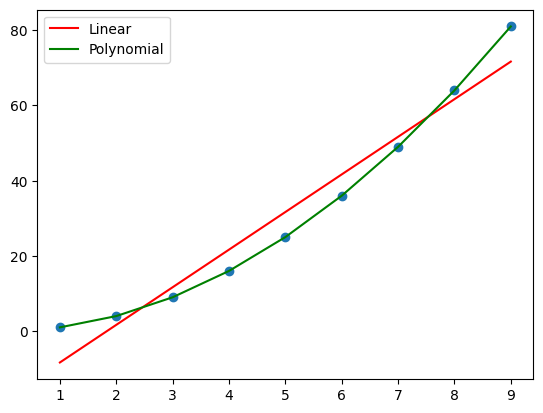

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X = np.arange(1,10).reshape(-1,1)
y = X**2

# linear model
lin = LinearRegression()
lin.fit(X,y)

# polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

lin2 = LinearRegression()
lin2.fit(X_poly,y)

plt.scatter(X,y)

plt.plot(X,lin.predict(X),color='red',label="Linear")

plt.plot(X,lin2.predict(X_poly),color='green',label="Polynomial")

plt.legend()
plt.show()

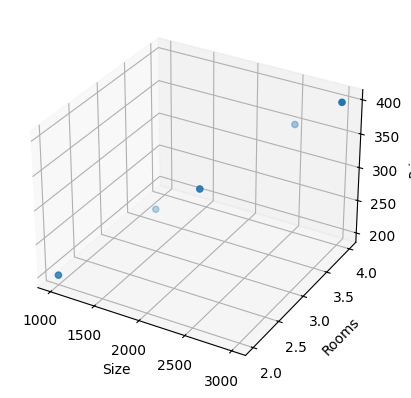

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

size = np.array([1000,1500,2000,2500,3000])
rooms = np.array([2,3,3,4,4])
price = np.array([200,250,300,350,400])

X = np.column_stack((size,rooms))

model = LinearRegression()
model.fit(X,price)

fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

ax.scatter(size,rooms,price)

ax.set_xlabel("Size")
ax.set_ylabel("Rooms")
ax.set_zlabel("Price")

plt.show()

In [108]:
np.random.uniform(0,1,100)

array([0.72658193, 0.56689329, 0.53908102, 0.37411152, 0.46601338,
       0.8021836 , 0.22171203, 0.9348263 , 0.72019991, 0.78995651,
       0.53263059, 0.84698394, 0.77425055, 0.3164226 , 0.70444171,
       0.56647678, 0.43232637, 0.1906772 , 0.08423503, 0.18831047,
       0.21375861, 0.36289262, 0.53965628, 0.78982377, 0.46990637,
       0.78169386, 0.68959524, 0.80717903, 0.69843027, 0.44076127,
       0.46696876, 0.25851858, 0.73302557, 0.09357177, 0.57558892,
       0.19799454, 0.84424118, 0.63673049, 0.7629513 , 0.67135484,
       0.06016592, 0.89631414, 0.49231672, 0.37683651, 0.43161733,
       0.94350871, 0.54712418, 0.1424749 , 0.23756901, 0.12618694,
       0.83963552, 0.09522119, 0.88488002, 0.15382645, 0.99970738,
       0.21377568, 0.7983287 , 0.66136137, 0.68248535, 0.83663254,
       0.34127135, 0.58063901, 0.5334628 , 0.35365279, 0.28298246,
       0.58548369, 0.59311521, 0.97540652, 0.92908044, 0.98393824,
       0.1132691 , 0.49291421, 0.86855992, 0.88204101, 0.12156

In [282]:
exp = np.random.randint(0,20,100)
salary = 1.5*exp + 1 + np.random.normal(0,1,100)
df = pd.DataFrame({"exp":exp,"salary":salary})

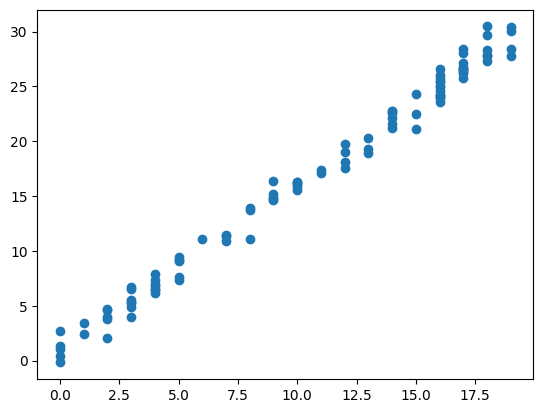

In [283]:
plt.scatter(df["exp"],df["salary"])

In [284]:
X = df["exp"]
y = df["salary"]

In [285]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.7, random_state = 0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((70,), (30,), (70,), (30,))

In [286]:
from sklearn.linear_model import LinearRegression

In [287]:
lr = LinearRegression()
lr.fit(X_train.values.reshape(-1,1),y_train.values.reshape(-1,1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [288]:
y_train_pred = lr.predict(X_train.values.reshape(-1,1)).reshape(-1,1)

In [289]:
X_train.squeeze().shape,y_train_pred.shape

((70,), (70, 1))

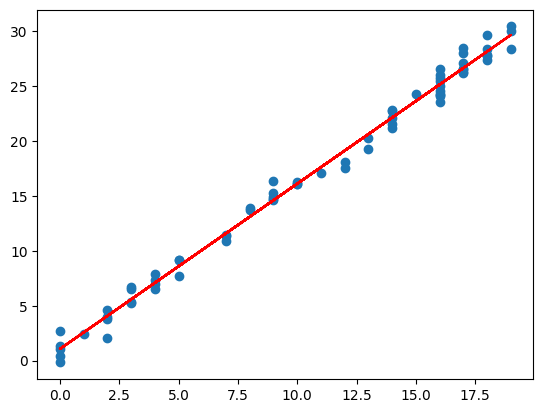

In [290]:
plt.scatter(x = X_train.squeeze(),y = y_train)
plt.plot(X_train.squeeze(),y_train_pred,color="red")

In [291]:
y_pred = lr.predict(X_test.values.reshape(-1,1))

In [292]:
r2_score(y_test,y_pred)

0.983312708866345

In [221]:
y_test.shape, lr.predict(y_test.values.reshape(-1,1)).reshape(-1,1)

((30,),
 array([[29.89886595],
        [11.82450601],
        [21.67823147],
        [ 7.58799254],
        [45.55325792],
        [46.65229446],
        [29.80548689],
        [23.70031926],
        [ 4.05071961],
        [10.51475432],
        [22.82931513],
        [33.22441291],
        [32.23446105],
        [24.92486504],
        [ 7.08923554],
        [ 6.58904441],
        [35.06305514],
        [35.49050455],
        [ 2.09152337],
        [16.13577426],
        [23.96472128],
        [24.40123683],
        [20.00876258],
        [45.47449186],
        [12.63076571],
        [20.5196367 ],
        [23.34754288],
        [43.00291813],
        [47.00968677],
        [41.56675622]]))

## Gradient Descent

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

X = np.linspace(0,10,100)
y = 4*X + 10 + np.random.randn(100)*5

#### Define Loss Function (MSE)

In [3]:
def compute_loss(w):
    y_pred = w * X
    return np.mean((y - y_pred)**2)

#### Create Loss Landscape

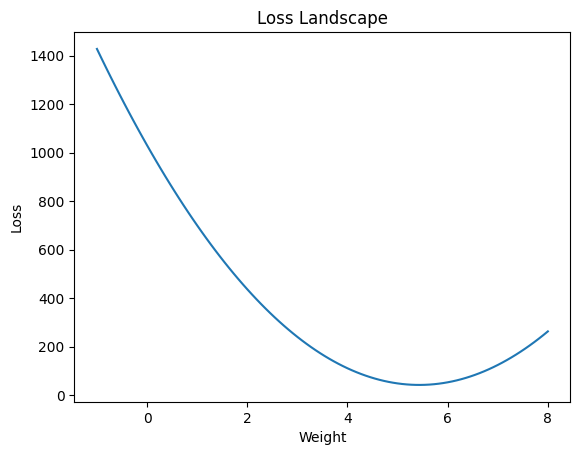

In [4]:
weights = np.linspace(-1,8,100)
losses = [compute_loss(w) for w in weights]

plt.plot(weights, losses)
plt.xlabel("Weight")
plt.ylabel("Loss")
plt.title("Loss Landscape")
plt.show()

Where the best slope exists.

The **lowest point = best model.**

#### Batch Gradient Descent Path

In [5]:
w = -1
lr = 0.001
path_gd = []

for i in range(20):
    
    y_pred = w * X
    gradient = np.mean(2*X*(y_pred-y))
    
    w = w - lr*gradient
    
    path_gd.append(w)

#### Stochastic Gradient Descent

In [6]:
w = -1
path_sgd = []

for i in range(20):
    
    idx = np.random.randint(0,len(X))
    
    xi = X[idx]
    yi = y[idx]
    
    y_pred = w*xi
    gradient = 2*xi*(y_pred-yi)
    
    w = w - lr*gradient
    
    path_sgd.append(w)

#### Mini-Batch Gradient Descent

In [7]:
w = -1
batch_size = 10
path_mbgd = []

for i in range(20):
    
    idx = np.random.choice(len(X),batch_size)
    
    xb = X[idx]
    yb = y[idx]
    
    y_pred = w*xb
    gradient = np.mean(2*xb*(y_pred-yb))
    
    w = w - lr*gradient
    
    path_mbgd.append(w)

#### Visualize Their Movement

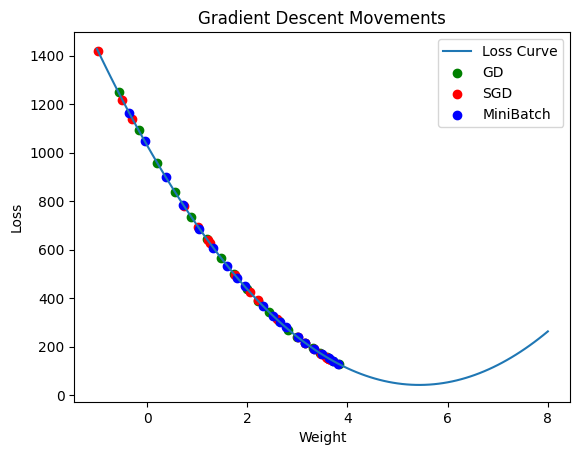

In [8]:
plt.plot(weights, losses, label="Loss Curve")

plt.scatter(path_gd,[compute_loss(w) for w in path_gd],label="GD",color="green")

plt.scatter(path_sgd,[compute_loss(w) for w in path_sgd],label="SGD",color="red")

plt.scatter(path_mbgd,[compute_loss(w) for w in path_mbgd],label="MiniBatch",color="blue")

plt.legend()
plt.xlabel("Weight")
plt.ylabel("Loss")
plt.title("Gradient Descent Movements")
plt.show()